In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install dagshub mlflow -q


In [ ]:
BASE_PATH = "/content/drive/MyDrive/Malay_folder/guvi/"
RESULTS_PATH = BASE_PATH + "Patrool_results/"
os.makedirs(RESULTS_PATH, exist_ok=True)

file_path = BASE_PATH + "Crimes_top_600k.csv"


In [ ]:
df = pd.read_csv(file_path, low_memory=False)
print("Dataset shape:", df.shape)


Dataset shape: (600000, 22)


In [ ]:
df['Date'] = pd.to_datetime(df['Date'])
df["Hour"] = df["Date"].dt.hour
df["Month"] = df["Date"].dt.month
df["Year"] = df["Date"].dt.year

df = df.dropna(subset=['Latitude', 'Longitude']).reset_index(drop=True)

scaler = StandardScaler()
df[['Lat_norm', 'Lon_norm']] = scaler.fit_transform(
    df[['Latitude', 'Longitude']]
)


In [ ]:
SAMPLE_SIZE = 50000
HIERARCHICAL_SAMPLE = 5000
RANDOM_STATE = 42

geo_features = df[['Lat_norm', 'Lon_norm']].copy()

sample_df = geo_features.sample(
    n=min(SAMPLE_SIZE, len(df)),
    random_state=RANDOM_STATE
)


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
!pip install dagshub mlflow -q

BASE_PATH = "/content/drive/MyDrive/Malay_folder/guvi/"
RESULTS_PATH = BASE_PATH + "Patrool_results/"
os.makedirs(RESULTS_PATH, exist_ok=True)

file_path = BASE_PATH + "Crimes_top_600k.csv"

df = pd.read_csv(file_path, low_memory=False)
print("Dataset shape:", df.shape)

df['Date'] = pd.to_datetime(df['Date'])
df["Hour"] = df["Date"].dt.hour
df["Month"] = df["Date"].dt.month
df["Year"] = df["Date"].dt.year

df = df.dropna(subset=['Latitude', 'Longitude']).reset_index(drop=True)

scaler = StandardScaler()
df[['Lat_norm', 'Lon_norm']] = scaler.fit_transform(
    df[['Latitude', 'Longitude']]
)



In [ ]:
from google.colab import drive
drive.mount('/content/drive')
!pip install dagshub mlflow -q

BASE_PATH = "/content/drive/MyDrive/Malay_folder/guvi/"
RESULTS_PATH = BASE_PATH + "Patrool_results_set4/"
os.makedirs(RESULTS_PATH, exist_ok=True)

file_path = BASE_PATH + "Crimes_top_600k.csv"

df = pd.read_csv(file_path, low_memory=False)
print("Dataset shape:", df.shape)

df['Date'] = pd.to_datetime(df['Date'])
df["Hour"] = df["Date"].dt.hour
df["Month"] = df["Date"].dt.month
df["Year"] = df["Date"].dt.year

df = df.dropna(subset=['Latitude', 'Longitude']).reset_index(drop=True)

scaler = StandardScaler()
df[['Lat_norm', 'Lon_norm']] = scaler.fit_transform(
    df[['Latitude', 'Longitude']]
)


# =============================================================================
# Step 4 & 5: Clustering Analysis + Dimensionality Reduction + MLflow Tracking
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from scipy.cluster.hierarchy import dendrogram, linkage
import joblib
import json
import warnings
warnings.filterwarnings("ignore")

# MLflow and DagsHub setup
import dagshub
import mlflow
import mlflow.sklearn

# Initialize DagsHub
dagshub.init(repo_owner='malaychand', repo_name='Patrol_IQ-_Smart_Safety_Analytics', mlflow=True)

# Configuration
SAMPLE_SIZE = 50000
HIERARCHICAL_SAMPLE = 5000
TEMPORAL_SAMPLE = 100000
RANDOM_STATE = 42

print("="*80)
print("PATROLIQ - CLUSTERING & DIMENSIONALITY REDUCTION WITH MLFLOW")
print("="*80)

# =============================================================================
# PART 1: GEOGRAPHIC CRIME HOTSPOT CLUSTERING
# =============================================================================

print("\n" + "="*80)
print("PART 1: GEOGRAPHIC CRIME HOTSPOT CLUSTERING")
print("="*80)

# Prepare geographic features
geo_features = df[['Lat_norm', 'Lon_norm']].copy()
sample_geo = geo_features.sample(n=min(SAMPLE_SIZE, len(df)), random_state=RANDOM_STATE)

# Store original indices for later mapping
sample_geo_indices = sample_geo.index

# -----------------------------------------------------------------------------
# 1.1 K-MEANS CLUSTERING (MANUAL K=6)
# -----------------------------------------------------------------------------

print("\n" + "-"*80)
print("1.1 K-MEANS CLUSTERING")
print("-"*80)

with mlflow.start_run(run_name="Geographic_KMeans_Clustering"):

    # Elbow Method to find optimal K
    print("\nFinding optimal K using Elbow Method...")
    inertia_list = []
    silhouette_scores = []
    K_range = range(2, 11)

    for k in K_range:
        kmeans_temp = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
        kmeans_temp.fit(sample_geo)
        inertia_list.append(kmeans_temp.inertia_)
        sil = silhouette_score(sample_geo, kmeans_temp.labels_)
        silhouette_scores.append(sil)
        print(f"K={k}: Inertia={kmeans_temp.inertia_:.2f}, Silhouette={sil:.4f}")

    # Plot Elbow Curve
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(K_range, inertia_list, marker='o', linewidth=2, markersize=8)
    ax1.axvline(x=6, color='red', linestyle='--', linewidth=2, label='Selected K=6')
    ax1.set_title("Elbow Method for Optimal K", fontsize=14, fontweight='bold')
    ax1.set_xlabel("Number of Clusters (K)", fontsize=12)
    ax1.set_ylabel("Inertia", fontsize=12)
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    ax2.plot(K_range, silhouette_scores, marker='s', color='green', linewidth=2, markersize=8)
    ax2.axvline(x=6, color='red', linestyle='--', linewidth=2, label='Selected K=6')
    ax2.set_title("Silhouette Score vs K", fontsize=14, fontweight='bold')
    ax2.set_xlabel("Number of Clusters (K)", fontsize=12)
    ax2.set_ylabel("Silhouette Score", fontsize=12)
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    elbow_path = RESULTS_PATH + "geo_kmeans_elbow_analysis.png"
    plt.savefig(elbow_path, dpi=300, bbox_inches='tight')
    plt.show()

    # MANUALLY SET K=6 (instead of automatic selection)
    best_k = 6
    auto_best_k_idx = np.argmax(silhouette_scores)
    auto_best_k = list(K_range)[auto_best_k_idx]

    print(f"\n📊 Analysis Results:")
    print(f"  • Automatic optimal K: {auto_best_k} (Silhouette Score: {silhouette_scores[auto_best_k_idx]:.4f})")
    print(f"  • Manually selected K: {best_k} (Silhouette Score: {silhouette_scores[best_k-2]:.4f})")
    print(f"\n✓ Using K={best_k} for final clustering (manual override)")

    # Final KMeans with K=6
    kmeans_final = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
    kmeans_labels = kmeans_final.fit_predict(sample_geo)
    sample_geo["KMeans_Cluster"] = kmeans_labels

    # Evaluation Metrics
    sil_kmeans = silhouette_score(sample_geo[['Lat_norm', 'Lon_norm']], kmeans_labels)
    db_kmeans = davies_bouldin_score(sample_geo[['Lat_norm', 'Lon_norm']], kmeans_labels)
    ch_kmeans = calinski_harabasz_score(sample_geo[['Lat_norm', 'Lon_norm']], kmeans_labels)

    print(f"\nKMeans Performance Metrics (K={best_k}):")
    print(f"  • Silhouette Score: {sil_kmeans:.4f}")
    print(f"  • Davies-Bouldin Index: {db_kmeans:.4f}")
    print(f"  • Calinski-Harabasz Score: {ch_kmeans:.2f}")

    # Cluster Statistics
    cluster_counts = pd.Series(kmeans_labels).value_counts().sort_index()
    print(f"\nCluster Distribution:")
    for cluster_id, count in cluster_counts.items():
        print(f"  Cluster {cluster_id}: {count} crimes ({count/len(kmeans_labels)*100:.1f}%)")

    # Visualization with improved colors
    plt.figure(figsize=(12, 10))
    scatter = plt.scatter(sample_geo["Lon_norm"], sample_geo["Lat_norm"],
                         c=kmeans_labels, cmap='tab10', s=10, alpha=0.6)
    centers = kmeans_final.cluster_centers_
    plt.scatter(centers[:, 1], centers[:, 0],
               c='red', marker='X', s=300, edgecolors='black', linewidths=2,
               label='Cluster Centers')
    plt.title(f"Geographic Crime Hotspots - KMeans (K={best_k})", fontsize=16, fontweight='bold')
    plt.xlabel("Longitude (normalized)", fontsize=12)
    plt.ylabel("Latitude (normalized)", fontsize=12)
    plt.colorbar(scatter, label='Cluster ID')
    plt.legend()
    plt.grid(True, alpha=0.3)
    kmeans_viz_path = RESULTS_PATH + "geo_kmeans_clusters.png"
    plt.savefig(kmeans_viz_path, dpi=300, bbox_inches='tight')
    plt.show()

    # Save model
    kmeans_model_path = RESULTS_PATH + "kmeans_geo_model.pkl"
    joblib.dump(kmeans_final, kmeans_model_path)

    # Log to MLflow
    mlflow.log_param("algorithm", "KMeans")
    mlflow.log_param("n_clusters", best_k)
    mlflow.log_param("n_clusters_auto", auto_best_k)
    mlflow.log_param("selection_method", "manual_override")
    mlflow.log_param("sample_size", len(sample_geo))
    mlflow.log_metric("silhouette_score", sil_kmeans)
    mlflow.log_metric("davies_bouldin_score", db_kmeans)
    mlflow.log_metric("calinski_harabasz_score", ch_kmeans)
    mlflow.log_artifact(elbow_path)
    mlflow.log_artifact(kmeans_viz_path)
    mlflow.sklearn.log_model(kmeans_final, "kmeans_model")

    print(f"\n✓ KMeans model saved to: {kmeans_model_path}")

# -----------------------------------------------------------------------------
# 1.2 DBSCAN CLUSTERING
# -----------------------------------------------------------------------------

print("\n" + "-"*80)
print("1.2 DBSCAN CLUSTERING")
print("-"*80)

with mlflow.start_run(run_name="Geographic_DBSCAN_Clustering"):

    # Test different eps values
    print("\nTesting different eps values for DBSCAN...")
    eps_values = [0.1, 0.2, 0.3, 0.4, 0.5]
    dbscan_results = []

    for eps in eps_values:
        dbscan_temp = DBSCAN(eps=eps, min_samples=20)
        labels_temp = dbscan_temp.fit_predict(sample_geo[['Lat_norm', 'Lon_norm']])

        n_clusters = len(set(labels_temp)) - (1 if -1 in labels_temp else 0)
        n_noise = list(labels_temp).count(-1)

        if n_clusters > 1:
            valid_idx = labels_temp != -1
            if valid_idx.sum() > 1:
                sil = silhouette_score(sample_geo.loc[valid_idx, ['Lat_norm', 'Lon_norm']],
                                      labels_temp[valid_idx])
            else:
                sil = -1
        else:
            sil = -1

        dbscan_results.append({
            'eps': eps,
            'n_clusters': n_clusters,
            'n_noise': n_noise,
            'silhouette': sil
        })
        print(f"eps={eps}: Clusters={n_clusters}, Noise={n_noise}, Silhouette={sil:.4f}")

    # Select best eps
    valid_results = [r for r in dbscan_results if r['silhouette'] > 0]
    if valid_results:
        best_eps_result = max(valid_results, key=lambda x: x['silhouette'])
        best_eps = best_eps_result['eps']
    else:
        best_eps = 0.3

    print(f"\n✓ Optimal eps selected: {best_eps}")

    # Final DBSCAN
    dbscan_final = DBSCAN(eps=best_eps, min_samples=20)
    dbscan_labels = dbscan_final.fit_predict(sample_geo[['Lat_norm', 'Lon_norm']])
    sample_geo["DBSCAN_Cluster"] = dbscan_labels

    # Metrics
    n_clusters_dbscan = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
    n_noise_dbscan = list(dbscan_labels).count(-1)

    valid_idx = dbscan_labels != -1
    if valid_idx.sum() > 1 and n_clusters_dbscan > 1:
        sil_dbscan = silhouette_score(sample_geo.loc[valid_idx, ['Lat_norm', 'Lon_norm']],
                                      dbscan_labels[valid_idx])
        db_dbscan = davies_bouldin_score(sample_geo.loc[valid_idx, ['Lat_norm', 'Lon_norm']],
                                         dbscan_labels[valid_idx])
        ch_dbscan = calinski_harabasz_score(sample_geo.loc[valid_idx, ['Lat_norm', 'Lon_norm']],
                                            dbscan_labels[valid_idx])
    else:
        sil_dbscan = db_dbscan = ch_dbscan = None

    print(f"\nDBSCAN Performance Metrics:")
    print(f"  • Number of Clusters: {n_clusters_dbscan}")
    print(f"  • Noise Points: {n_noise_dbscan} ({n_noise_dbscan/len(dbscan_labels)*100:.1f}%)")
    print(f"  • Silhouette Score: {sil_dbscan:.4f}" if sil_dbscan else "  • Silhouette Score: N/A")
    print(f"  • Davies-Bouldin Index: {db_dbscan:.4f}" if db_dbscan else "  • Davies-Bouldin Index: N/A")

    # Visualization
    plt.figure(figsize=(12, 10))
    colors = dbscan_labels.copy()
    colors[colors == -1] = -1  # Noise points
    scatter = plt.scatter(sample_geo["Lon_norm"], sample_geo["Lat_norm"],
                         c=colors, cmap='tab10', s=10, alpha=0.6)
    plt.title(f"Geographic Crime Hotspots - DBSCAN (eps={best_eps})", fontsize=16, fontweight='bold')
    plt.xlabel("Longitude (normalized)", fontsize=12)
    plt.ylabel("Latitude (normalized)", fontsize=12)
    plt.colorbar(scatter, label='Cluster ID (-1 = Noise)')
    plt.grid(True, alpha=0.3)
    dbscan_viz_path = RESULTS_PATH + "geo_dbscan_clusters.png"
    plt.savefig(dbscan_viz_path, dpi=300, bbox_inches='tight')
    plt.show()

    # Save model
    dbscan_model_path = RESULTS_PATH + "dbscan_geo_model.pkl"
    joblib.dump(dbscan_final, dbscan_model_path)

    # Log to MLflow
    mlflow.log_param("algorithm", "DBSCAN")
    mlflow.log_param("eps", best_eps)
    mlflow.log_param("min_samples", 20)
    mlflow.log_param("n_clusters", n_clusters_dbscan)
    mlflow.log_param("n_noise", n_noise_dbscan)
    if sil_dbscan:
        mlflow.log_metric("silhouette_score", sil_dbscan)
        mlflow.log_metric("davies_bouldin_score", db_dbscan)
        mlflow.log_metric("calinski_harabasz_score", ch_dbscan)
    mlflow.log_artifact(dbscan_viz_path)
    mlflow.sklearn.log_model(dbscan_final, "dbscan_model")

    print(f"\n✓ DBSCAN model saved to: {dbscan_model_path}")

# -----------------------------------------------------------------------------
# 1.3 HIERARCHICAL CLUSTERING
# -----------------------------------------------------------------------------

print("\n" + "-"*80)
print("1.3 HIERARCHICAL CLUSTERING")
print("-"*80)

with mlflow.start_run(run_name="Geographic_Hierarchical_Clustering"):

    # Use smaller sample for hierarchical
    hier_sample = sample_geo[['Lat_norm', 'Lon_norm']].sample(
        n=min(HIERARCHICAL_SAMPLE, len(sample_geo)),
        random_state=RANDOM_STATE
    )

    print(f"\nUsing {len(hier_sample)} samples for Hierarchical Clustering...")

    # Test different number of clusters
    print("\nTesting different cluster numbers...")
    n_clusters_range = range(3, 9)
    hier_scores = []

    for n_clust in n_clusters_range:
        hier_temp = AgglomerativeClustering(n_clusters=n_clust, linkage='ward')
        labels_temp = hier_temp.fit_predict(hier_sample)
        sil = silhouette_score(hier_sample, labels_temp)
        hier_scores.append(sil)
        print(f"n_clusters={n_clust}: Silhouette={sil:.4f}")

    # Select best n_clusters
    best_n_idx = np.argmax(hier_scores)
    best_n_clusters = list(n_clusters_range)[best_n_idx]
    print(f"\n✓ Optimal n_clusters selected: {best_n_clusters}")

    # Final Hierarchical Clustering
    hierarchical_final = AgglomerativeClustering(n_clusters=best_n_clusters, linkage='ward')
    hier_labels = hierarchical_final.fit_predict(hier_sample)

    # Metrics
    sil_hier = silhouette_score(hier_sample, hier_labels)
    db_hier = davies_bouldin_score(hier_sample, hier_labels)
    ch_hier = calinski_harabasz_score(hier_sample, hier_labels)

    print(f"\nHierarchical Performance Metrics:")
    print(f"  • Silhouette Score: {sil_hier:.4f}")
    print(f"  • Davies-Bouldin Index: {db_hier:.4f}")
    print(f"  • Calinski-Harabasz Score: {ch_hier:.2f}")

    # Dendrogram
    print("\nGenerating dendrogram...")
    linked = linkage(hier_sample, method='ward')

    plt.figure(figsize=(14, 7))
    dendrogram(linked, truncate_mode='level', p=5, color_threshold=0)
    plt.title("Hierarchical Clustering Dendrogram (Ward Linkage)", fontsize=16, fontweight='bold')
    plt.xlabel("Sample Index", fontsize=12)
    plt.ylabel("Distance", fontsize=12)
    plt.grid(True, alpha=0.3, axis='y')
    dendro_path = RESULTS_PATH + "geo_hierarchical_dendrogram.png"
    plt.savefig(dendro_path, dpi=300, bbox_inches='tight')
    plt.show()

    # Visualization
    plt.figure(figsize=(12, 10))
    scatter = plt.scatter(hier_sample["Lon_norm"], hier_sample["Lat_norm"],
                         c=hier_labels, cmap='tab10', s=20, alpha=0.7)
    plt.title(f"Geographic Crime Hotspots - Hierarchical (n={best_n_clusters})",
              fontsize=16, fontweight='bold')
    plt.xlabel("Longitude (normalized)", fontsize=12)
    plt.ylabel("Latitude (normalized)", fontsize=12)
    plt.colorbar(scatter, label='Cluster ID')
    plt.grid(True, alpha=0.3)
    hier_viz_path = RESULTS_PATH + "geo_hierarchical_clusters.png"
    plt.savefig(hier_viz_path, dpi=300, bbox_inches='tight')
    plt.show()

    # Save model
    hier_model_path = RESULTS_PATH + "hierarchical_geo_model.pkl"
    joblib.dump(hierarchical_final, hier_model_path)

    # Log to MLflow
    mlflow.log_param("algorithm", "Hierarchical")
    mlflow.log_param("n_clusters", best_n_clusters)
    mlflow.log_param("linkage", "ward")
    mlflow.log_param("sample_size", len(hier_sample))
    mlflow.log_metric("silhouette_score", sil_hier)
    mlflow.log_metric("davies_bouldin_score", db_hier)
    mlflow.log_metric("calinski_harabasz_score", ch_hier)
    mlflow.log_artifact(dendro_path)
    mlflow.log_artifact(hier_viz_path)
    mlflow.sklearn.log_model(hierarchical_final, "hierarchical_model")

    print(f"\n✓ Hierarchical model saved to: {hier_model_path}")

# -----------------------------------------------------------------------------
# 1.4 GEOGRAPHIC CLUSTERING COMPARISON
# -----------------------------------------------------------------------------

print("\n" + "-"*80)
print("1.4 GEOGRAPHIC CLUSTERING COMPARISON")
print("-"*80)

geo_comparison = pd.DataFrame({
    "Algorithm": ["KMeans (K=6)", "DBSCAN", "Hierarchical"],
    "Silhouette Score": [sil_kmeans, sil_dbscan if sil_dbscan else 0, sil_hier],
    "Davies-Bouldin Score": [db_kmeans, db_dbscan if db_dbscan else 0, db_hier],
    "Calinski-Harabasz Score": [ch_kmeans, ch_dbscan if ch_dbscan else 0, ch_hier],
    "N_Clusters": [best_k, n_clusters_dbscan, best_n_clusters]
})

print("\nGeographic Clustering Performance Comparison:")
print(geo_comparison.to_string(index=False))

# Save comparison
geo_comparison_path = RESULTS_PATH + "geo_clustering_comparison.csv"
geo_comparison.to_csv(geo_comparison_path, index=False)

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

geo_comparison.plot(x='Algorithm', y='Silhouette Score', kind='bar', ax=axes[0],
                    legend=False, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
axes[0].set_title('Silhouette Score Comparison', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Score', fontsize=12)
axes[0].axhline(y=0.5, color='r', linestyle='--', label='Target: 0.5')
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=45, ha='right')

geo_comparison.plot(x='Algorithm', y='Davies-Bouldin Score', kind='bar', ax=axes[1],
                    legend=False, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
axes[1].set_title('Davies-Bouldin Index Comparison', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Score (Lower is Better)', fontsize=12)
axes[1].grid(True, alpha=0.3, axis='y')
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45, ha='right')

geo_comparison.plot(x='Algorithm', y='Calinski-Harabasz Score', kind='bar', ax=axes[2],
                    legend=False, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
axes[2].set_title('Calinski-Harabasz Score Comparison', fontsize=14, fontweight='bold')
axes[2].set_ylabel('Score (Higher is Better)', fontsize=12)
axes[2].grid(True, alpha=0.3, axis='y')
plt.setp(axes[2].xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
geo_comp_viz_path = RESULTS_PATH + "geo_clustering_comparison.png"
plt.savefig(geo_comp_viz_path, dpi=300, bbox_inches='tight')
plt.show()

# Select best algorithm based on silhouette score
best_geo_algo = geo_comparison.loc[geo_comparison['Silhouette Score'].idxmax(), 'Algorithm']
print(f"\n✓ BEST GEOGRAPHIC CLUSTERING ALGORITHM: {best_geo_algo}")
print(f"   (Based on highest Silhouette Score)")

ModuleNotFoundError: No module named 'dagshub'

Initialized MLflow to track repo "malaychand/Patrol_IQ-_Smart_Safety_Analytics"

Repository malaychand/Patrol_IQ-_Smart_Safety_Analytics initialized!

PATROLIQ - CLUSTERING & DIMENSIONALITY REDUCTION WITH MLFLOW

PART 1: GEOGRAPHIC CRIME HOTSPOT CLUSTERING

--------------------------------------------------------------------------------
1.1 K-MEANS CLUSTERING
--------------------------------------------------------------------------------

Finding optimal K using Elbow Method...
K=2: Inertia=47782.55, Silhouette=0.4496
K=3: Inertia=32031.61, Silhouette=0.4272
K=4: Inertia=24654.34, Silhouette=0.4099
K=5: Inertia=19998.84, Silhouette=0.3984
K=6: Inertia=16254.88, Silhouette=0.3954
K=7: Inertia=13667.11, Silhouette=0.3998
K=8: Inertia=11849.45, Silhouette=0.3994
K=9: Inertia=10285.74, Silhouette=0.4040
K=10: Inertia=9020.22, Silhouette=0.4158


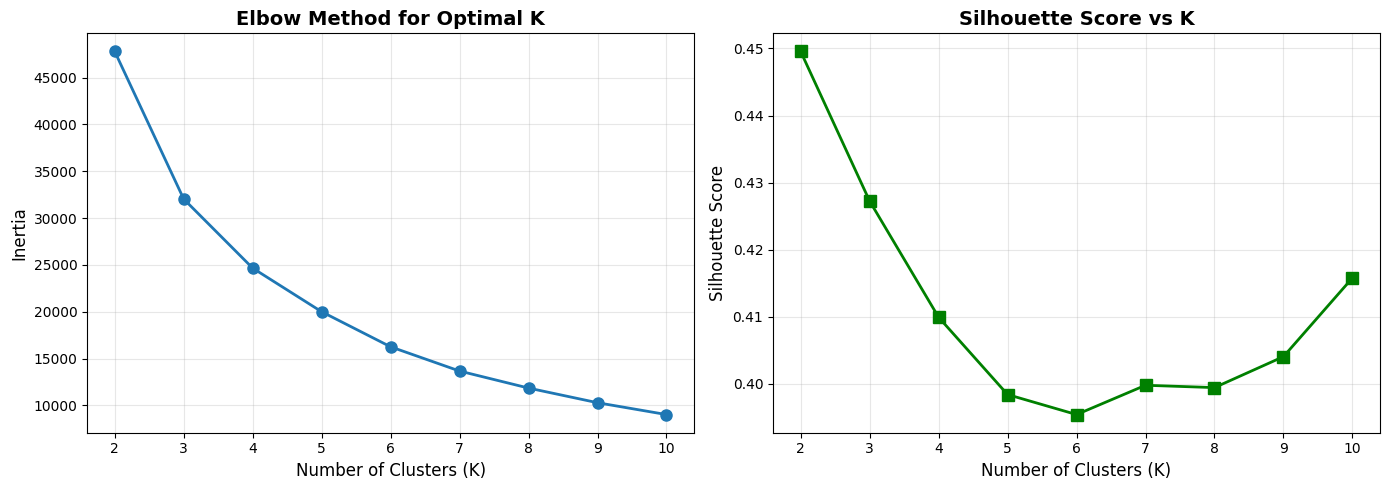


✓ Optimal K selected: 2 (Silhouette Score: 0.4496)

KMeans Performance Metrics:
  • Silhouette Score: 0.4496
  • Davies-Bouldin Index: 0.8297
  • Calinski-Harabasz Score: 54619.93

Cluster Distribution:
  Cluster 0: 29351 crimes (58.7%)
  Cluster 1: 20649 crimes (41.3%)


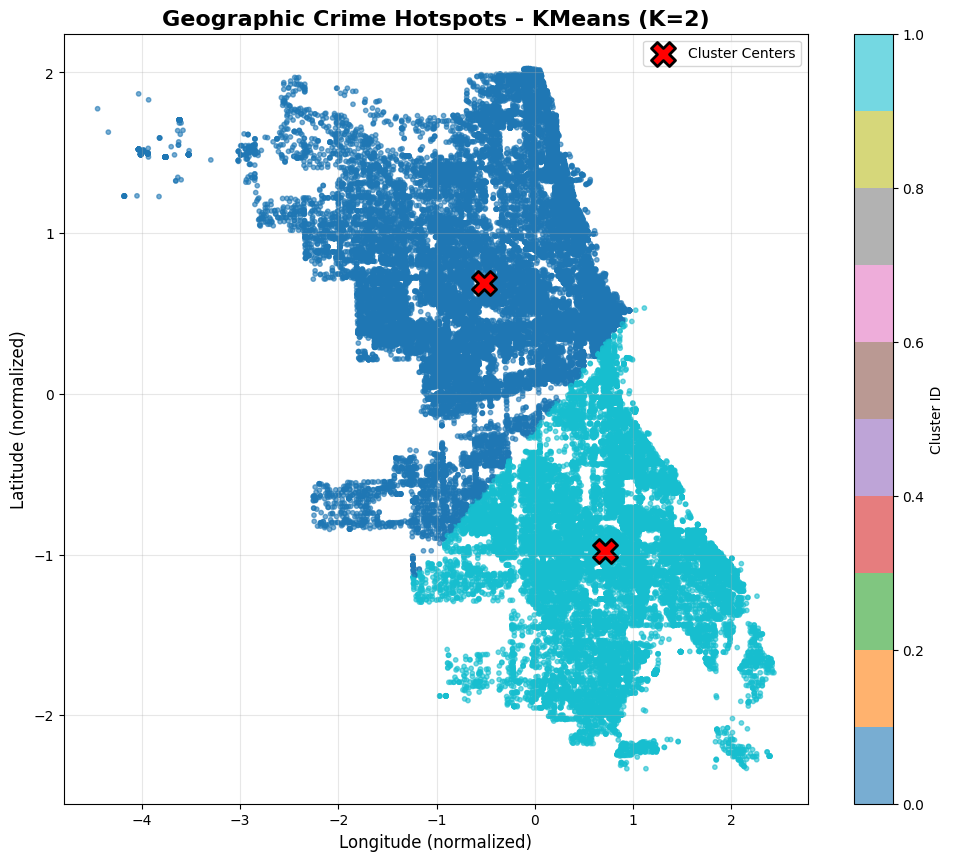

2026/02/16 02:11:13 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



✓ KMeans model saved to: /content/drive/MyDrive/Malay_folder/guvi/Patrool_results/kmeans_geo_model.pkl
🏃 View run Geographic_KMeans_Clustering at: https://dagshub.com/malaychand/Patrol_IQ-_Smart_Safety_Analytics.mlflow/#/experiments/0/runs/0b06908a0f494104a3c4d4e40f63cc03
🧪 View experiment at: https://dagshub.com/malaychand/Patrol_IQ-_Smart_Safety_Analytics.mlflow/#/experiments/0

--------------------------------------------------------------------------------
1.2 DBSCAN CLUSTERING
--------------------------------------------------------------------------------

Testing different eps values for DBSCAN...
eps=0.1: Clusters=9, Noise=90, Silhouette=-0.1215
eps=0.2: Clusters=2, Noise=14, Silhouette=0.5531
eps=0.3: Clusters=1, Noise=3, Silhouette=-1.0000
eps=0.4: Clusters=1, Noise=0, Silhouette=-1.0000
eps=0.5: Clusters=1, Noise=0, Silhouette=-1.0000

✓ Optimal eps selected: 0.2

DBSCAN Performance Metrics:
  • Number of Clusters: 2
  • Noise Points: 14 (0.0%)
  • Silhouette Score: 0.5531


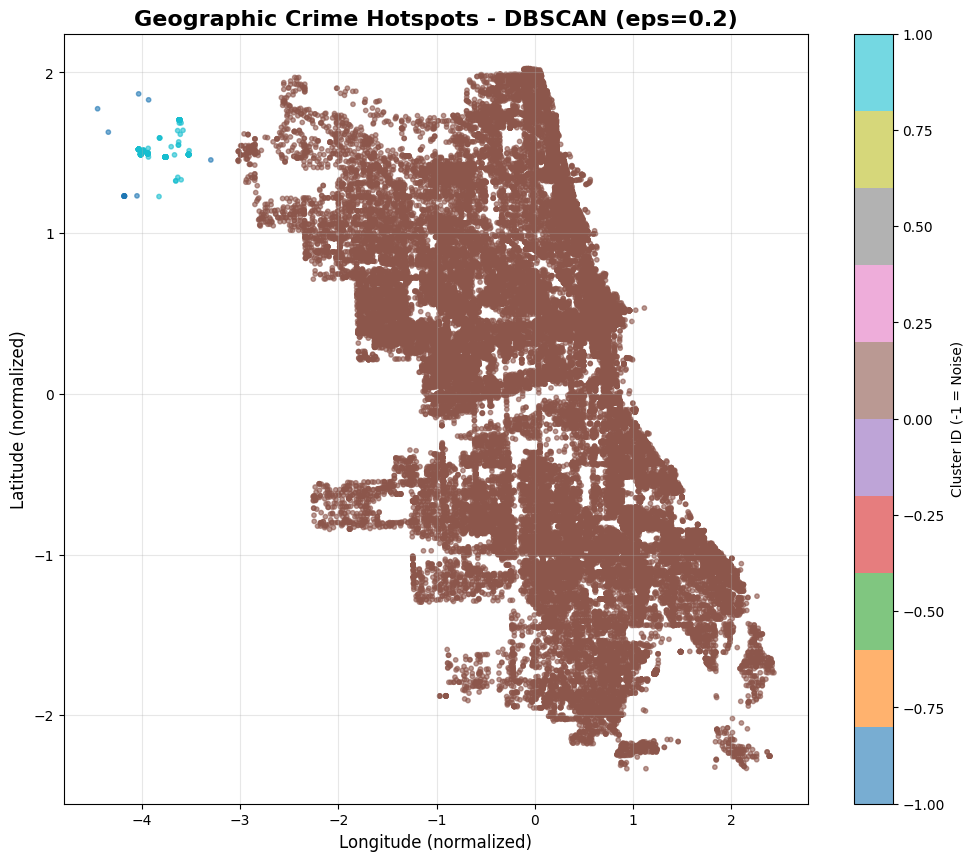

2026/02/16 02:13:39 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/02/16 02:13:45 WARNING mlflow.sklearn: Model was missing function: predict. Not logging python_function flavor!



✓ DBSCAN model saved to: /content/drive/MyDrive/Malay_folder/guvi/Patrool_results/dbscan_geo_model.pkl
🏃 View run Geographic_DBSCAN_Clustering at: https://dagshub.com/malaychand/Patrol_IQ-_Smart_Safety_Analytics.mlflow/#/experiments/0/runs/851b26c3cdcd443898785c5dd264978f
🧪 View experiment at: https://dagshub.com/malaychand/Patrol_IQ-_Smart_Safety_Analytics.mlflow/#/experiments/0

--------------------------------------------------------------------------------
1.3 HIERARCHICAL CLUSTERING
--------------------------------------------------------------------------------

Using 5000 samples for Hierarchical Clustering...

Testing different cluster numbers...
n_clusters=3: Silhouette=0.3880
n_clusters=4: Silhouette=0.3790
n_clusters=5: Silhouette=0.3589
n_clusters=6: Silhouette=0.3699
n_clusters=7: Silhouette=0.3487
n_clusters=8: Silhouette=0.3602

✓ Optimal n_clusters selected: 3

Hierarchical Performance Metrics:
  • Silhouette Score: 0.3880
  • Davies-Bouldin Index: 0.9765
  • Calinski-

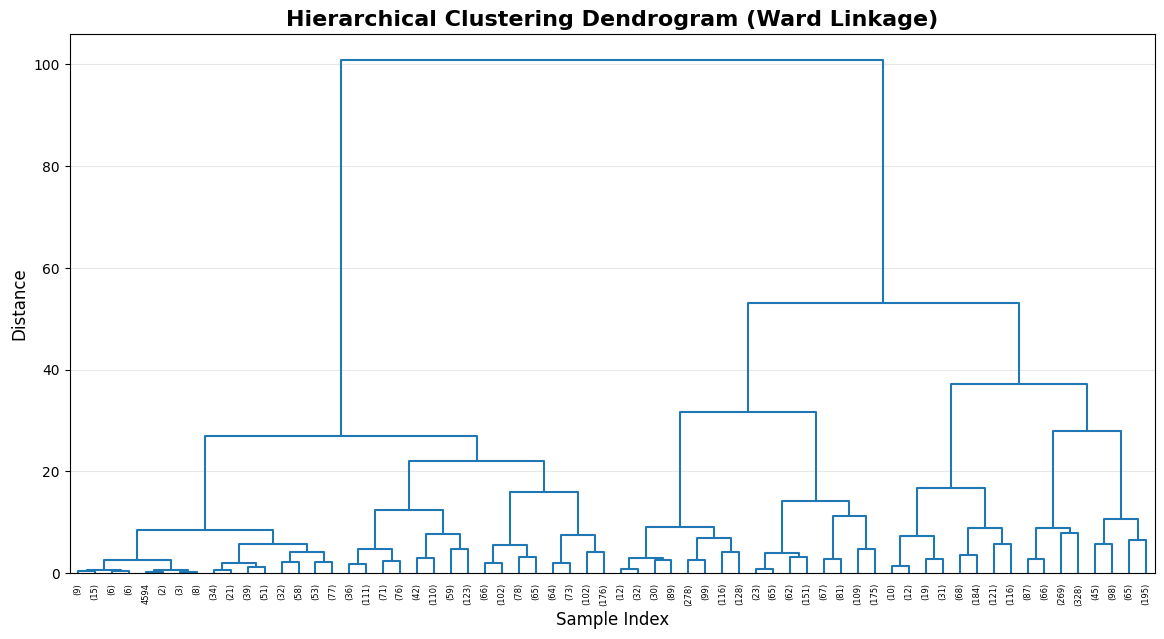

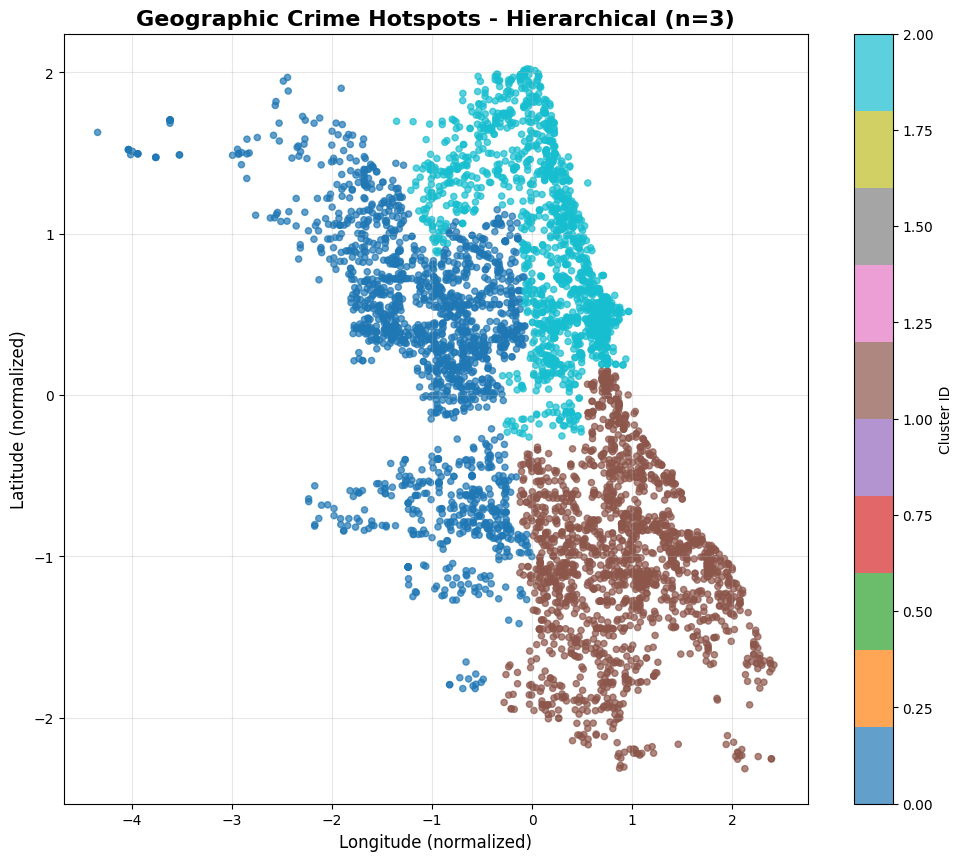

2026/02/16 02:14:11 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/02/16 02:14:16 WARNING mlflow.sklearn: Model was missing function: predict. Not logging python_function flavor!



✓ Hierarchical model saved to: /content/drive/MyDrive/Malay_folder/guvi/Patrool_results/hierarchical_geo_model.pkl
🏃 View run Geographic_Hierarchical_Clustering at: https://dagshub.com/malaychand/Patrol_IQ-_Smart_Safety_Analytics.mlflow/#/experiments/0/runs/453e836961064c4d9d5fa52cd461abd8
🧪 View experiment at: https://dagshub.com/malaychand/Patrol_IQ-_Smart_Safety_Analytics.mlflow/#/experiments/0

--------------------------------------------------------------------------------
1.4 GEOGRAPHIC CLUSTERING COMPARISON
--------------------------------------------------------------------------------

Geographic Clustering Performance Comparison:
   Algorithm  Silhouette Score  Davies-Bouldin Score  Calinski-Harabasz Score  N_Clusters
      KMeans          0.449551              0.829742             54619.933140           2
      DBSCAN          0.553085              0.351042              2166.886740           2
Hierarchical          0.388032              0.976532              4673.658225    

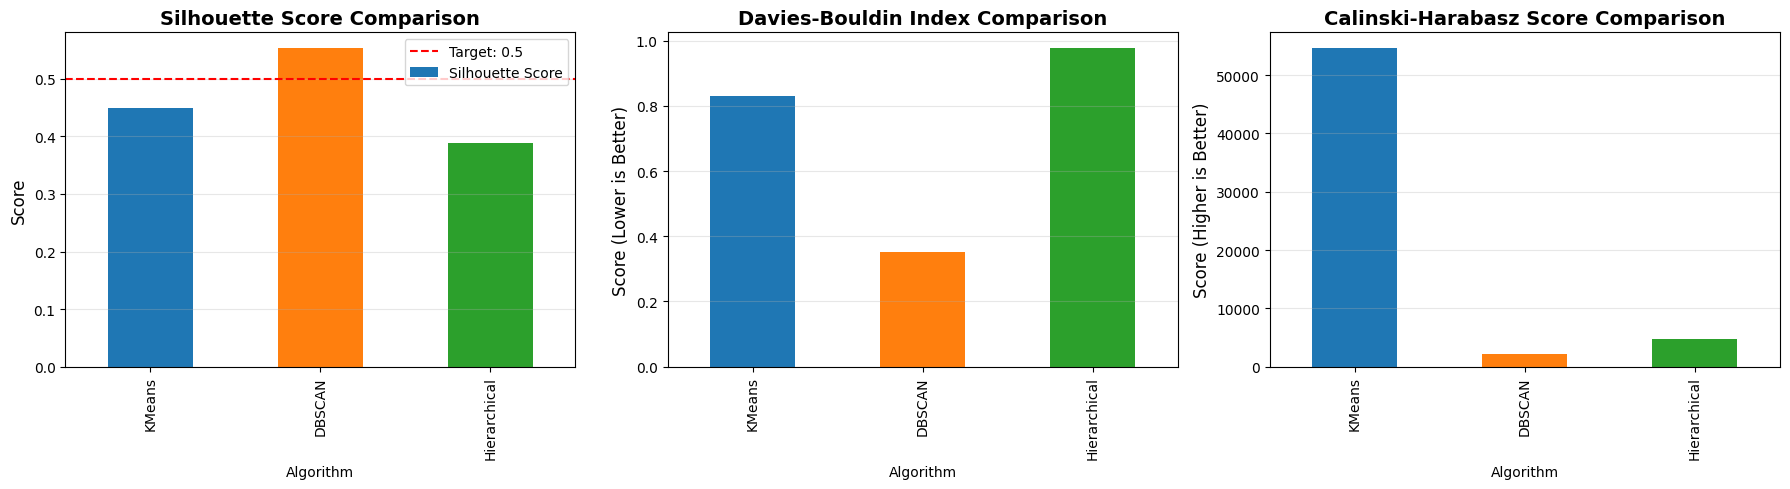


✓ BEST GEOGRAPHIC CLUSTERING ALGORITHM: DBSCAN

Checking and creating temporal features...
Current columns in df: ['ID', 'Case Number', 'Date', 'Block', 'IUCR', 'Primary Type', 'Description', 'Location Description', 'Arrest', 'Domestic', 'Beat', 'District', 'Ward', 'Community Area', 'FBI Code', 'X Coordinate', 'Y Coordinate', 'Year', 'Updated On', 'Latitude', 'Longitude', 'Location', 'Hour', 'Month', 'Lat_norm', 'Lon_norm']
✓ Temporal features created/verified

PART 2: TEMPORAL PATTERN CLUSTERING
✓ All required temporal columns present: ['Hour', 'DayOfWeek', 'Month', 'Season']

Finding optimal K for temporal patterns...
K=3: Inertia=227426.00, Silhouette=0.2649
K=4: Inertia=192492.26, Silhouette=0.2644
K=5: Inertia=163498.77, Silhouette=0.2917
K=6: Inertia=139728.17, Silhouette=0.2912
K=7: Inertia=124324.77, Silhouette=0.2930


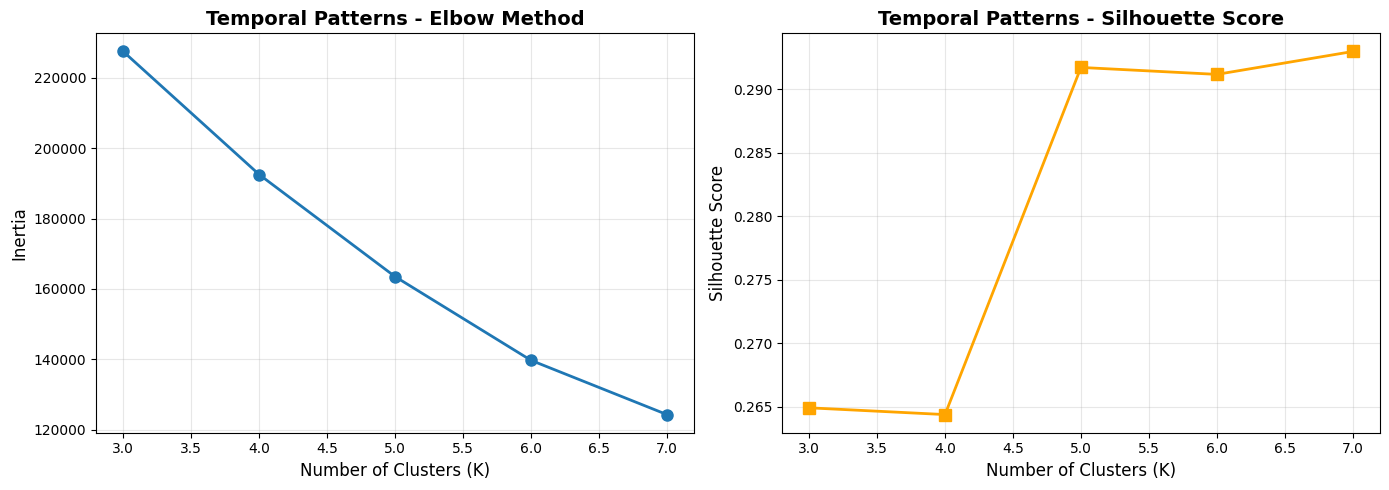


✓ Optimal K for temporal patterns: 7

Temporal Clustering Performance:
  • Silhouette Score: 0.2930
  • Davies-Bouldin Index: 1.0739
  • Calinski-Harabasz Score: 37003.82

Temporal Crime Patterns by Cluster:

Cluster 0 (6693 crimes, 6.7%):
  • Peak Hour: 0
  • Most Common Day: Sunday
  • Most Common Month: 12
  • Most Common Season: Winter

Cluster 1 (19792 crimes, 19.8%):
  • Peak Hour: 12
  • Most Common Day: Monday
  • Most Common Month: 10
  • Most Common Season: Fall

Cluster 2 (22444 crimes, 22.4%):
  • Peak Hour: 12
  • Most Common Day: Saturday
  • Most Common Month: 8
  • Most Common Season: Fall

Cluster 3 (18013 crimes, 18.0%):
  • Peak Hour: 0
  • Most Common Day: Thursday
  • Most Common Month: 8
  • Most Common Season: Fall

Cluster 4 (13703 crimes, 13.7%):
  • Peak Hour: 15
  • Most Common Day: Monday
  • Most Common Month: 4
  • Most Common Season: Spring

Cluster 5 (9400 crimes, 9.4%):
  • Peak Hour: 0
  • Most Common Day: Thursday
  • Most Common Month: 5
  • Most Co

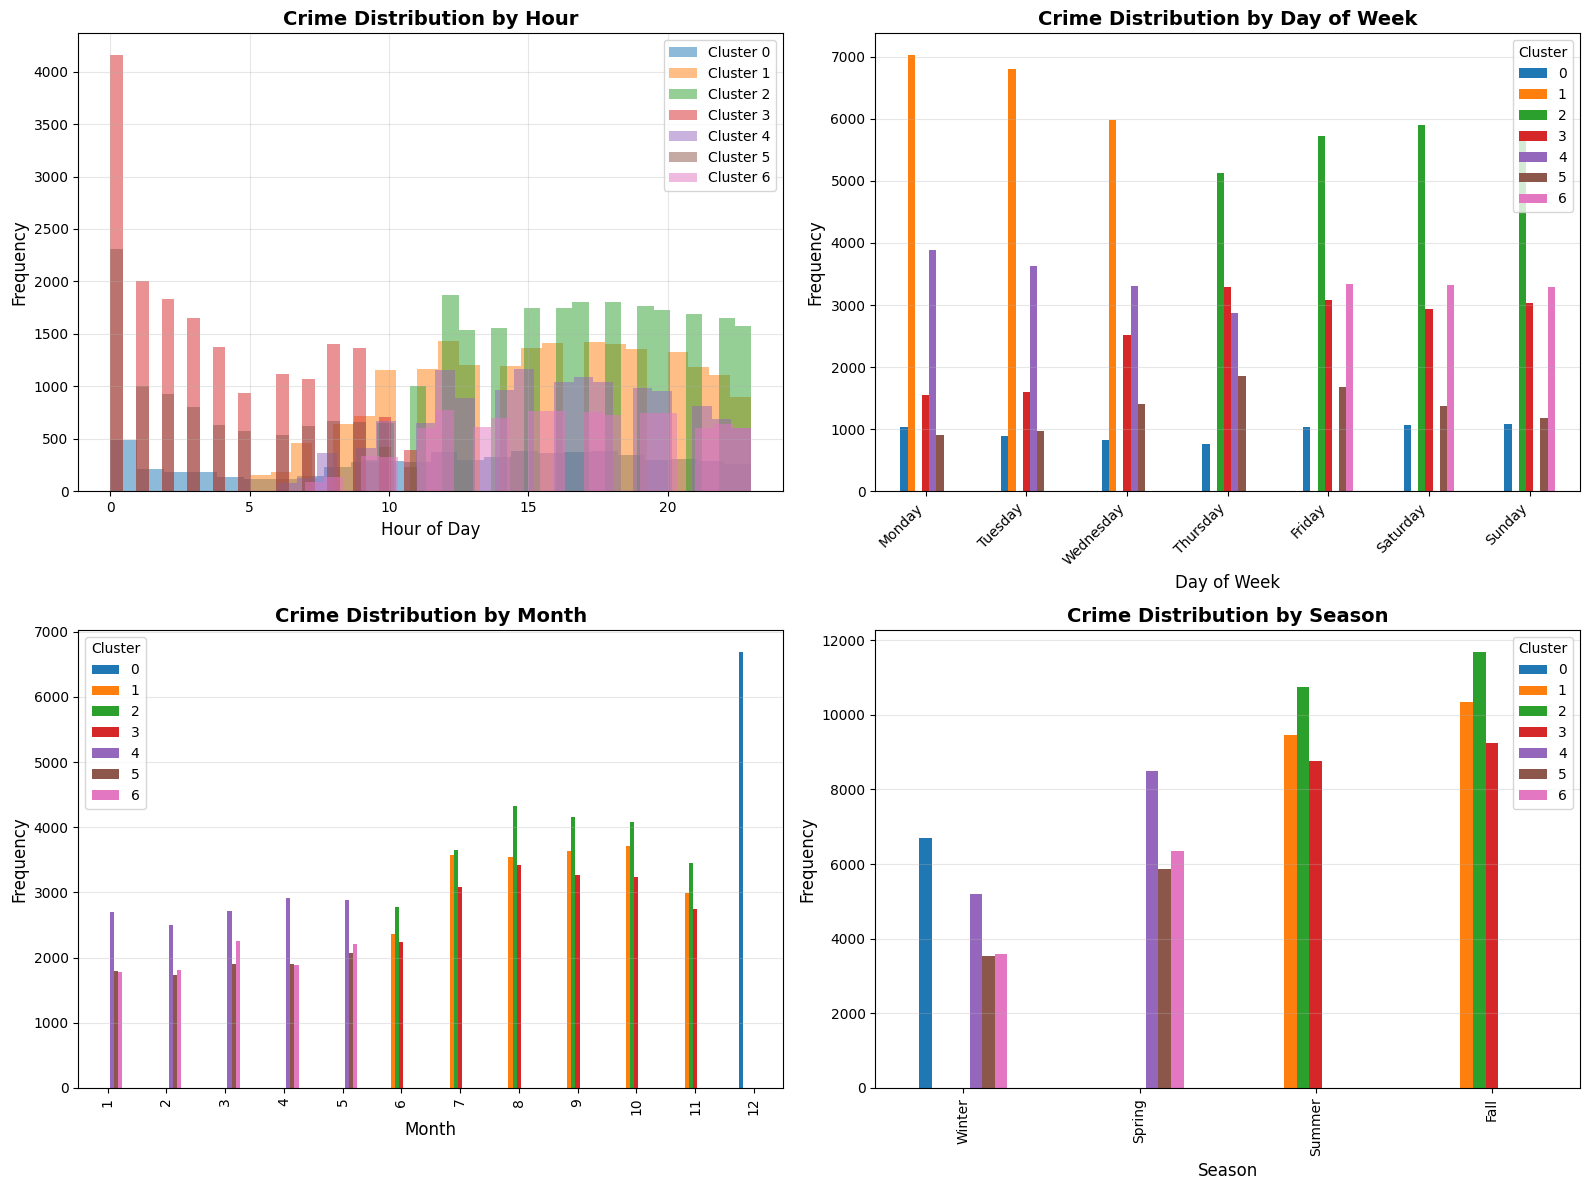

2026/02/16 02:26:41 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



✓ Temporal KMeans model saved to: /content/drive/MyDrive/Malay_folder/guvi/Patrool_results/kmeans_temporal_model.pkl
🏃 View run Temporal_KMeans_Clustering at: https://dagshub.com/malaychand/Patrol_IQ-_Smart_Safety_Analytics.mlflow/#/experiments/0/runs/888ee393ce1e4d618b402b3a4beeb825
🧪 View experiment at: https://dagshub.com/malaychand/Patrol_IQ-_Smart_Safety_Analytics.mlflow/#/experiments/0

PART 3: DIMENSIONALITY REDUCTION

Preparing comprehensive feature set...

Available features (11): Hour, Day, Month, Year, Lat_norm, Lon_norm, Lat_bin, Lon_bin, DayOfWeek_encoded, Season_encoded, Arrest_flag

Using 50000 samples with 11 features

--------------------------------------------------------------------------------
3.1 PCA - PRINCIPAL COMPONENT ANALYSIS
--------------------------------------------------------------------------------

Variance Explained:
  • 70% variance: 5 components
  • 80% variance: 6 components
  • 90% variance: 8 components


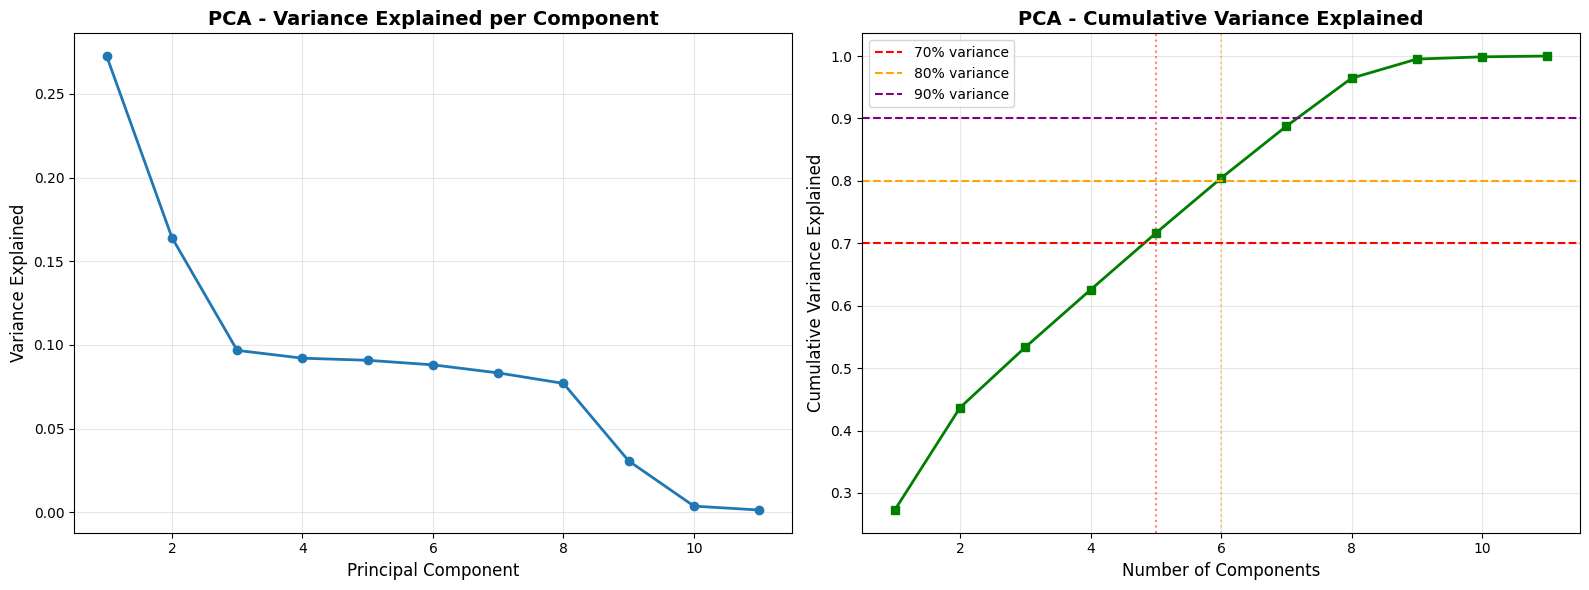


PCA with 3 components:
  • PC1 variance: 0.2726
  • PC2 variance: 0.1641
  • PC3 variance: 0.0967
  • Total variance explained: 0.5335

Top 5 Most Important Features per Principal Component:

PC1:
  • Lat_bin: 0.5031
  • Lat_norm: 0.5025
  • Lon_norm: 0.4982
  • Lon_bin: 0.4955
  • Arrest_flag: 0.0226

PC2:
  • Month: 0.6681
  • Season_encoded: 0.6006
  • Year: 0.4345
  • Arrest_flag: 0.0615
  • DayOfWeek_encoded: 0.0153

PC3:
  • Hour: 0.6779
  • Arrest_flag: 0.6158
  • DayOfWeek_encoded: 0.3676
  • Day: 0.1328
  • Season_encoded: 0.0504


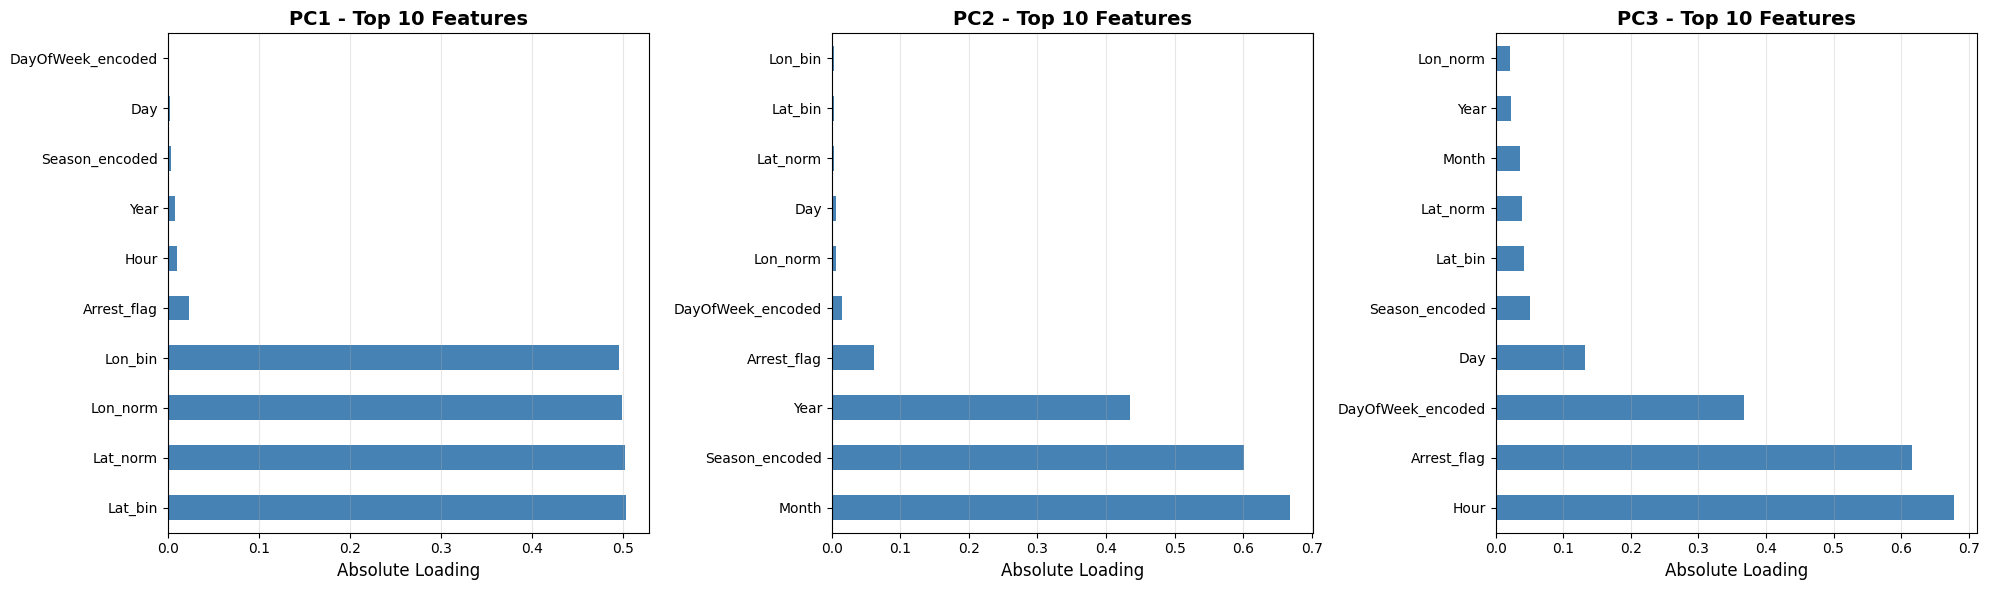

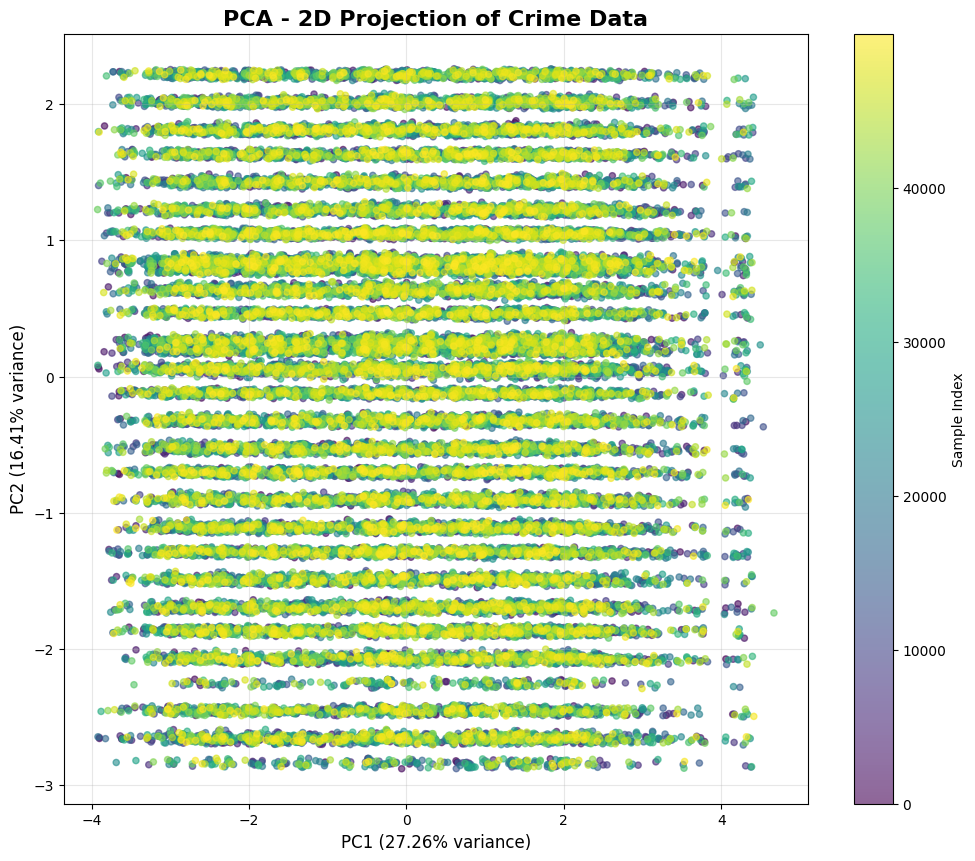

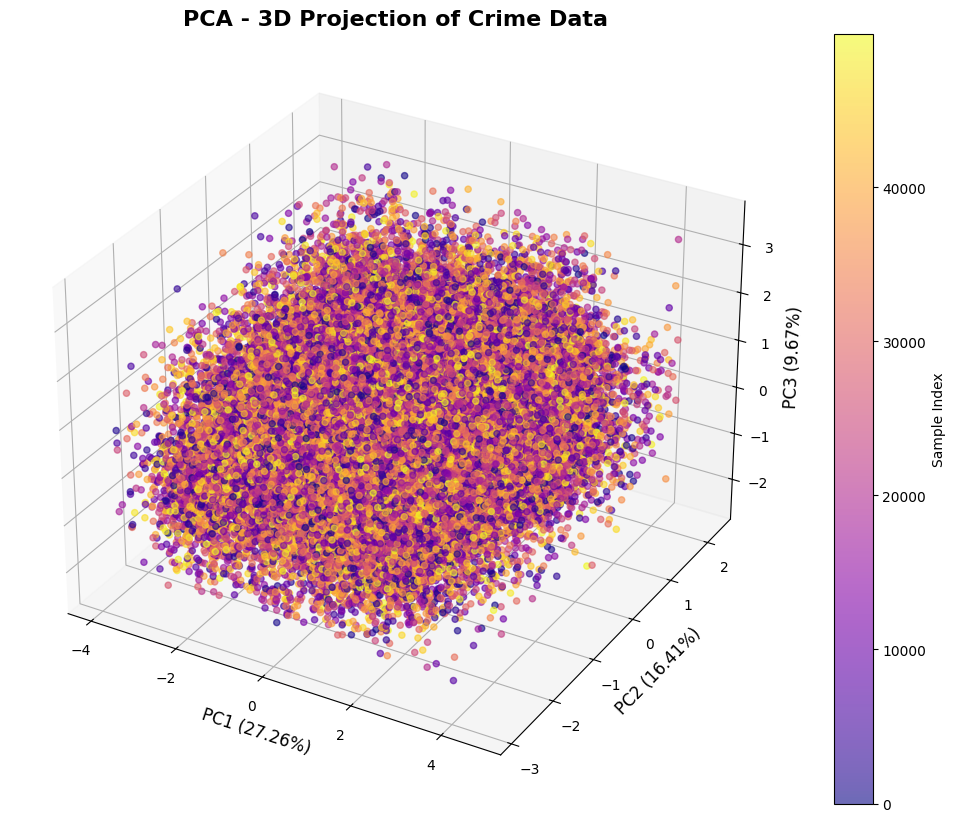

2026/02/16 02:27:25 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/02/16 02:27:30 WARNING mlflow.sklearn: Model was missing function: predict. Not logging python_function flavor!



✓ PCA model saved to: /content/drive/MyDrive/Malay_folder/guvi/Patrool_results/pca_model.pkl
🏃 View run PCA_Dimensionality_Reduction at: https://dagshub.com/malaychand/Patrol_IQ-_Smart_Safety_Analytics.mlflow/#/experiments/0/runs/3579d60c5810494f87deb39ed83db961
🧪 View experiment at: https://dagshub.com/malaychand/Patrol_IQ-_Smart_Safety_Analytics.mlflow/#/experiments/0

--------------------------------------------------------------------------------
3.2 t-SNE - t-DISTRIBUTED STOCHASTIC NEIGHBOR EMBEDDING
--------------------------------------------------------------------------------

Using 10000 samples for t-SNE...

Running t-SNE with perplexity=30...
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 10000 samples in 0.016s...
[t-SNE] Computed neighbors for 10000 samples in 1.915s...
[t-SNE] Computed conditional probabilities for sample 1000 / 10000
[t-SNE] Computed conditional probabilities for sample 2000 / 10000
[t-SNE] Computed conditional probabilities for sample 3000 

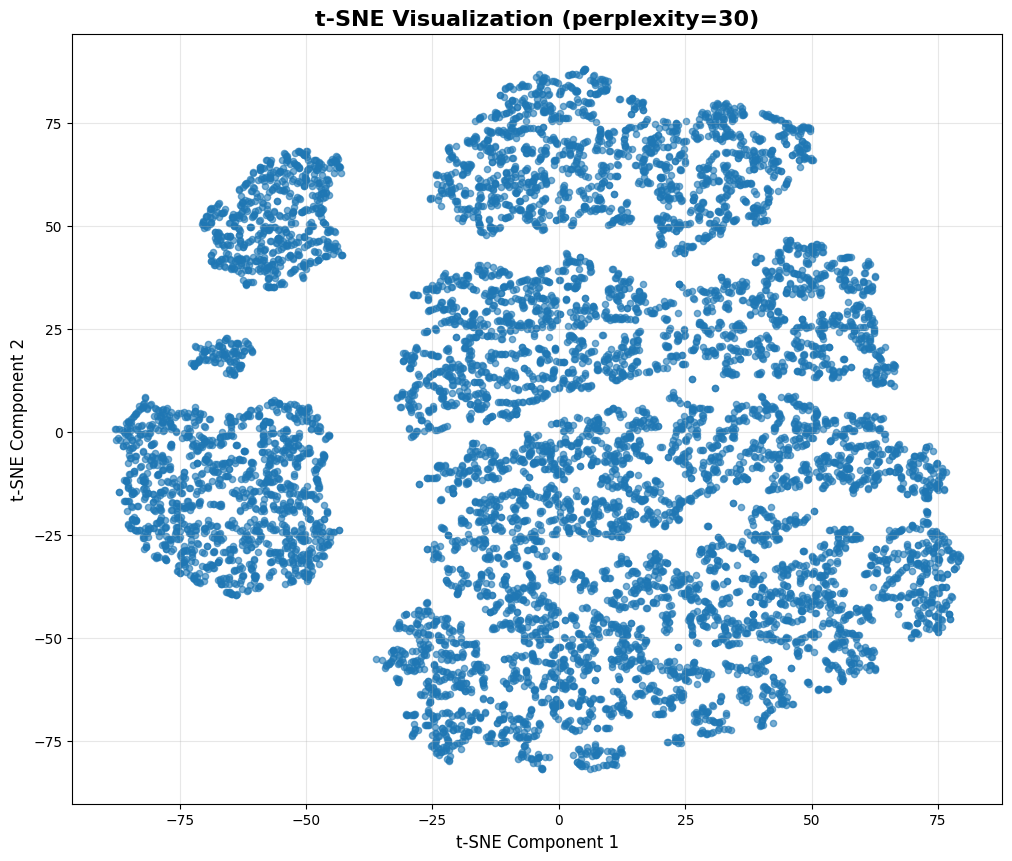


Running t-SNE with perplexity=50...
[t-SNE] Computing 151 nearest neighbors...
[t-SNE] Indexed 10000 samples in 0.014s...
[t-SNE] Computed neighbors for 10000 samples in 3.047s...
[t-SNE] Computed conditional probabilities for sample 1000 / 10000
[t-SNE] Computed conditional probabilities for sample 2000 / 10000
[t-SNE] Computed conditional probabilities for sample 3000 / 10000
[t-SNE] Computed conditional probabilities for sample 4000 / 10000
[t-SNE] Computed conditional probabilities for sample 5000 / 10000
[t-SNE] Computed conditional probabilities for sample 6000 / 10000
[t-SNE] Computed conditional probabilities for sample 7000 / 10000
[t-SNE] Computed conditional probabilities for sample 8000 / 10000
[t-SNE] Computed conditional probabilities for sample 9000 / 10000
[t-SNE] Computed conditional probabilities for sample 10000 / 10000
[t-SNE] Mean sigma: 0.870264
[t-SNE] KL divergence after 250 iterations with early exaggeration: 82.850388
[t-SNE] KL divergence after 1000 iteratio

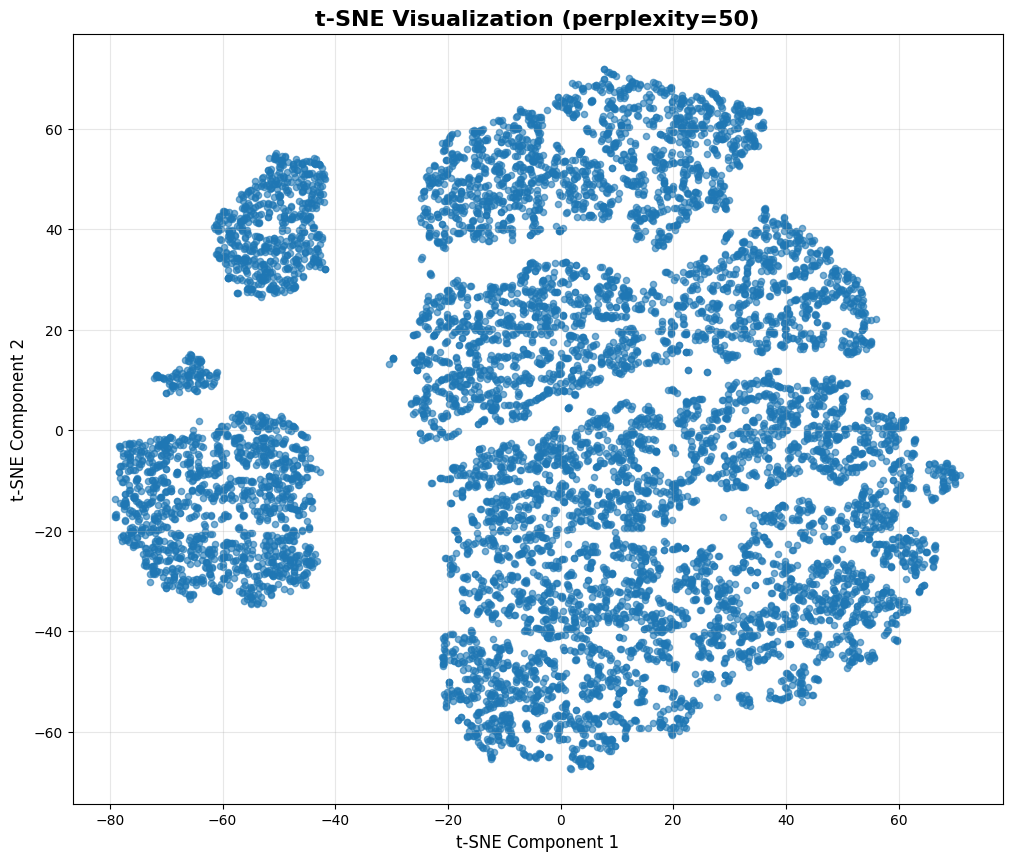

2026/02/16 02:32:23 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/02/16 02:32:23 WARNING mlflow.sklearn: Model was missing function: predict. Not logging python_function flavor!



✓ t-SNE model saved to: /content/drive/MyDrive/Malay_folder/guvi/Patrool_results/tsne_model.pkl
🏃 View run tSNE_Dimensionality_Reduction at: https://dagshub.com/malaychand/Patrol_IQ-_Smart_Safety_Analytics.mlflow/#/experiments/0/runs/b1c315665c8b4ad0b1d6755679a5189e
🧪 View experiment at: https://dagshub.com/malaychand/Patrol_IQ-_Smart_Safety_Analytics.mlflow/#/experiments/0

FINAL SUMMARY AND MODEL REGISTRY

✓ All models and results saved successfully!

Results directory: /content/drive/MyDrive/Malay_folder/guvi/Patrool_results/

Saved files:
  • Geographic clustering models (KMeans, DBSCAN, Hierarchical)
  • Temporal clustering model (KMeans)
  • Dimensionality reduction models (PCA, t-SNE)
  • All visualizations and comparisons
  • Model performance metrics
  • Comprehensive summary (JSON)

MODEL PERFORMANCE SUMMARY
{
  "Geographic Clustering": {
    "Best Algorithm": "DBSCAN",
    "KMeans": {
      "n_clusters": 2,
      "silhouette_score": 0.44955054599584277,
      "davies_bouldi

In [ ]:
# =============================================================================
# Step 4 & 5: Clustering Analysis + Dimensionality Reduction + MLflow Tracking
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from scipy.cluster.hierarchy import dendrogram, linkage
import joblib
import json
import warnings
warnings.filterwarnings("ignore")

# MLflow and DagsHub setup
import dagshub
import mlflow
import mlflow.sklearn

# Initialize DagsHub
dagshub.init(repo_owner='malaychand', repo_name='Patrol_IQ-_Smart_Safety_Analytics', mlflow=True)

# Configuration
SAMPLE_SIZE = 50000
HIERARCHICAL_SAMPLE = 5000
TEMPORAL_SAMPLE = 100000
RANDOM_STATE = 42

print("="*80)
print("PATROLIQ - CLUSTERING & DIMENSIONALITY REDUCTION WITH MLFLOW")
print("="*80)

# =============================================================================
# PART 1: GEOGRAPHIC CRIME HOTSPOT CLUSTERING
# =============================================================================

print("\n" + "="*80)
print("PART 1: GEOGRAPHIC CRIME HOTSPOT CLUSTERING")
print("="*80)

# Prepare geographic features
geo_features = df[['Lat_norm', 'Lon_norm']].copy()
sample_geo = geo_features.sample(n=min(SAMPLE_SIZE, len(df)), random_state=RANDOM_STATE)

# Store original indices for later mapping
sample_geo_indices = sample_geo.index

# -----------------------------------------------------------------------------
# 1.1 K-MEANS CLUSTERING
# -----------------------------------------------------------------------------
# -----------------------------------------------------------------------------
# 1.1 K-MEANS CLUSTERING
# -----------------------------------------------------------------------------

print("\n" + "-"*80)
print("1.1 K-MEANS CLUSTERING")
print("-"*80)

with mlflow.start_run(run_name="Geographic_KMeans_Clustering"):

    # Elbow Method to find optimal K
    print("\nFinding optimal K using Elbow Method...")
    inertia_list = []
    silhouette_scores = []
    K_range = range(2, 11)

    for k in K_range:
        kmeans_temp = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
        kmeans_temp.fit(sample_geo)
        inertia_list.append(kmeans_temp.inertia_)
        sil = silhouette_score(sample_geo, kmeans_temp.labels_)
        silhouette_scores.append(sil)
        print(f"K={k}: Inertia={kmeans_temp.inertia_:.2f}, Silhouette={sil:.4f}")

    # Plot Elbow Curve
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(K_range, inertia_list, marker='o', linewidth=2, markersize=8)
    ax1.set_title("Elbow Method for Optimal K", fontsize=14, fontweight='bold')
    ax1.set_xlabel("Number of Clusters (K)", fontsize=12)
    ax1.set_ylabel("Inertia", fontsize=12)
    ax1.grid(True, alpha=0.3)

    ax2.plot(K_range, silhouette_scores, marker='s', color='green', linewidth=2, markersize=8)
    ax2.set_title("Silhouette Score vs K", fontsize=14, fontweight='bold')
    ax2.set_xlabel("Number of Clusters (K)", fontsize=12)
    ax2.set_ylabel("Silhouette Score", fontsize=12)
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    elbow_path = RESULTS_PATH + "geo_kmeans_elbow_analysis.png"
    plt.savefig(elbow_path, dpi=300, bbox_inches='tight')
    plt.show()

    # MANUALLY SET K=6 (instead of automatic selection)
    best_k = 6
    auto_best_k_idx = np.argmax(silhouette_scores)
    auto_best_k = list(K_range)[auto_best_k_idx]

    print(f"\n📊 Analysis Results:")
    print(f"  • Automatic optimal K: {auto_best_k} (Silhouette Score: {silhouette_scores[auto_best_k_idx]:.4f})")
    print(f"  • Manually selected K: {best_k} (Silhouette Score: {silhouette_scores[best_k-2]:.4f})")
    print(f"\n✓ Using K={best_k} for final clustering")

    # Final KMeans with K=6
    kmeans_final = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
    kmeans_labels = kmeans_final.fit_predict(sample_geo)
    sample_geo["KMeans_Cluster"] = kmeans_labels

    # Evaluation Metrics
    sil_kmeans = silhouette_score(sample_geo[['Lat_norm', 'Lon_norm']], kmeans_labels)
    db_kmeans = davies_bouldin_score(sample_geo[['Lat_norm', 'Lon_norm']], kmeans_labels)
    ch_kmeans = calinski_harabasz_score(sample_geo[['Lat_norm', 'Lon_norm']], kmeans_labels)

    print(f"\nKMeans Performance Metrics (K={best_k}):")
    print(f"  • Silhouette Score: {sil_kmeans:.4f}")
    print(f"  • Davies-Bouldin Index: {db_kmeans:.4f}")
    print(f"  • Calinski-Harabasz Score: {ch_kmeans:.2f}")

    # Cluster Statistics
    cluster_counts = pd.Series(kmeans_labels).value_counts().sort_index()
    print(f"\nCluster Distribution:")
    for cluster_id, count in cluster_counts.items():
        print(f"  Cluster {cluster_id}: {count} crimes ({count/len(kmeans_labels)*100:.1f}%)")

    # Visualization
    plt.figure(figsize=(12, 10))
    scatter = plt.scatter(sample_geo["Lon_norm"], sample_geo["Lat_norm"],
                         c=kmeans_labels, cmap='tab10', s=10, alpha=0.6)
    centers = kmeans_final.cluster_centers_
    plt.scatter(centers[:, 1], centers[:, 0],
               c='red', marker='X', s=300, edgecolors='black', linewidths=2,
               label='Cluster Centers')
    plt.title(f"Geographic Crime Hotspots - KMeans (K={best_k})", fontsize=16, fontweight='bold')
    plt.xlabel("Longitude (normalized)", fontsize=12)
    plt.ylabel("Latitude (normalized)", fontsize=12)
    plt.colorbar(scatter, label='Cluster ID')
    plt.legend()
    plt.grid(True, alpha=0.3)
    kmeans_viz_path = RESULTS_PATH + "geo_kmeans_clusters.png"
    plt.savefig(kmeans_viz_path, dpi=300, bbox_inches='tight')
    plt.show()

    # Save model
    kmeans_model_path = RESULTS_PATH + "kmeans_geo_model.pkl"
    joblib.dump(kmeans_final, kmeans_model_path)

    # Log to MLflow
    mlflow.log_param("algorithm", "KMeans")
    mlflow.log_param("n_clusters", best_k)
    mlflow.log_param("n_clusters_auto", auto_best_k)
    mlflow.log_param("selection_method", "manual")
    mlflow.log_param("sample_size", len(sample_geo))
    mlflow.log_metric("silhouette_score", sil_kmeans)
    mlflow.log_metric("davies_bouldin_score", db_kmeans)
    mlflow.log_metric("calinski_harabasz_score", ch_kmeans)
    mlflow.log_artifact(elbow_path)
    mlflow.log_artifact(kmeans_viz_path)
    mlflow.sklearn.log_model(kmeans_final, "kmeans_model")

    print(f"\n✓ KMeans model saved to: {kmeans_model_path}")
# -----------------------------------------------------------------------------
# 1.2 DBSCAN CLUSTERING
# -----------------------------------------------------------------------------

print("\n" + "-"*80)
print("1.2 DBSCAN CLUSTERING")
print("-"*80)

with mlflow.start_run(run_name="Geographic_DBSCAN_Clustering"):

    # Test different eps values
    print("\nTesting different eps values for DBSCAN...")
    eps_values = [0.1, 0.2, 0.3, 0.4, 0.5]
    dbscan_results = []

    for eps in eps_values:
        dbscan_temp = DBSCAN(eps=eps, min_samples=20)
        labels_temp = dbscan_temp.fit_predict(sample_geo[['Lat_norm', 'Lon_norm']])

        n_clusters = len(set(labels_temp)) - (1 if -1 in labels_temp else 0)
        n_noise = list(labels_temp).count(-1)

        if n_clusters > 1:
            valid_idx = labels_temp != -1
            if valid_idx.sum() > 1:
                sil = silhouette_score(sample_geo.loc[valid_idx, ['Lat_norm', 'Lon_norm']],
                                      labels_temp[valid_idx])
            else:
                sil = -1
        else:
            sil = -1

        dbscan_results.append({
            'eps': eps,
            'n_clusters': n_clusters,
            'n_noise': n_noise,
            'silhouette': sil
        })
        print(f"eps={eps}: Clusters={n_clusters}, Noise={n_noise}, Silhouette={sil:.4f}")

    # Select best eps
    valid_results = [r for r in dbscan_results if r['silhouette'] > 0]
    if valid_results:
        best_eps_result = max(valid_results, key=lambda x: x['silhouette'])
        best_eps = best_eps_result['eps']
    else:
        best_eps = 0.3

    print(f"\n✓ Optimal eps selected: {best_eps}")

    # Final DBSCAN
    dbscan_final = DBSCAN(eps=best_eps, min_samples=20)
    dbscan_labels = dbscan_final.fit_predict(sample_geo[['Lat_norm', 'Lon_norm']])
    sample_geo["DBSCAN_Cluster"] = dbscan_labels

    # Metrics
    n_clusters_dbscan = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
    n_noise_dbscan = list(dbscan_labels).count(-1)

    valid_idx = dbscan_labels != -1
    if valid_idx.sum() > 1 and n_clusters_dbscan > 1:
        sil_dbscan = silhouette_score(sample_geo.loc[valid_idx, ['Lat_norm', 'Lon_norm']],
                                      dbscan_labels[valid_idx])
        db_dbscan = davies_bouldin_score(sample_geo.loc[valid_idx, ['Lat_norm', 'Lon_norm']],
                                         dbscan_labels[valid_idx])
        ch_dbscan = calinski_harabasz_score(sample_geo.loc[valid_idx, ['Lat_norm', 'Lon_norm']],
                                            dbscan_labels[valid_idx])
    else:
        sil_dbscan = db_dbscan = ch_dbscan = None

    print(f"\nDBSCAN Performance Metrics:")
    print(f"  • Number of Clusters: {n_clusters_dbscan}")
    print(f"  • Noise Points: {n_noise_dbscan} ({n_noise_dbscan/len(dbscan_labels)*100:.1f}%)")
    print(f"  • Silhouette Score: {sil_dbscan:.4f}" if sil_dbscan else "  • Silhouette Score: N/A")
    print(f"  • Davies-Bouldin Index: {db_dbscan:.4f}" if db_dbscan else "  • Davies-Bouldin Index: N/A")

    # Visualization
    plt.figure(figsize=(12, 10))
    colors = dbscan_labels.copy()
    colors[colors == -1] = -1  # Noise points
    scatter = plt.scatter(sample_geo["Lon_norm"], sample_geo["Lat_norm"],
                         c=colors, cmap='tab10', s=10, alpha=0.6)
    plt.title(f"Geographic Crime Hotspots - DBSCAN (eps={best_eps})", fontsize=16, fontweight='bold')
    plt.xlabel("Longitude (normalized)", fontsize=12)
    plt.ylabel("Latitude (normalized)", fontsize=12)
    plt.colorbar(scatter, label='Cluster ID (-1 = Noise)')
    plt.grid(True, alpha=0.3)
    dbscan_viz_path = RESULTS_PATH + "geo_dbscan_clusters.png"
    plt.savefig(dbscan_viz_path, dpi=300, bbox_inches='tight')
    plt.show()

    # Save model
    dbscan_model_path = RESULTS_PATH + "dbscan_geo_model.pkl"
    joblib.dump(dbscan_final, dbscan_model_path)

    # Log to MLflow
    mlflow.log_param("algorithm", "DBSCAN")
    mlflow.log_param("eps", best_eps)
    mlflow.log_param("min_samples", 20)
    mlflow.log_param("n_clusters", n_clusters_dbscan)
    mlflow.log_param("n_noise", n_noise_dbscan)
    if sil_dbscan:
        mlflow.log_metric("silhouette_score", sil_dbscan)
        mlflow.log_metric("davies_bouldin_score", db_dbscan)
        mlflow.log_metric("calinski_harabasz_score", ch_dbscan)
    mlflow.log_artifact(dbscan_viz_path)
    mlflow.sklearn.log_model(dbscan_final, "dbscan_model")

    print(f"\n✓ DBSCAN model saved to: {dbscan_model_path}")

# -----------------------------------------------------------------------------
# 1.3 HIERARCHICAL CLUSTERING
# -----------------------------------------------------------------------------

print("\n" + "-"*80)
print("1.3 HIERARCHICAL CLUSTERING")
print("-"*80)

with mlflow.start_run(run_name="Geographic_Hierarchical_Clustering"):

    # Use smaller sample for hierarchical
    hier_sample = sample_geo[['Lat_norm', 'Lon_norm']].sample(
        n=min(HIERARCHICAL_SAMPLE, len(sample_geo)),
        random_state=RANDOM_STATE
    )

    print(f"\nUsing {len(hier_sample)} samples for Hierarchical Clustering...")

    # Test different number of clusters
    print("\nTesting different cluster numbers...")
    n_clusters_range = range(3, 9)
    hier_scores = []

    for n_clust in n_clusters_range:
        hier_temp = AgglomerativeClustering(n_clusters=n_clust, linkage='ward')
        labels_temp = hier_temp.fit_predict(hier_sample)
        sil = silhouette_score(hier_sample, labels_temp)
        hier_scores.append(sil)
        print(f"n_clusters={n_clust}: Silhouette={sil:.4f}")

    # Select best n_clusters
    best_n_idx = np.argmax(hier_scores)
    best_n_clusters = list(n_clusters_range)[best_n_idx]
    print(f"\n✓ Optimal n_clusters selected: {best_n_clusters}")

    # Final Hierarchical Clustering
    hierarchical_final = AgglomerativeClustering(n_clusters=best_n_clusters, linkage='ward')
    hier_labels = hierarchical_final.fit_predict(hier_sample)

    # Metrics
    sil_hier = silhouette_score(hier_sample, hier_labels)
    db_hier = davies_bouldin_score(hier_sample, hier_labels)
    ch_hier = calinski_harabasz_score(hier_sample, hier_labels)

    print(f"\nHierarchical Performance Metrics:")
    print(f"  • Silhouette Score: {sil_hier:.4f}")
    print(f"  • Davies-Bouldin Index: {db_hier:.4f}")
    print(f"  • Calinski-Harabasz Score: {ch_hier:.2f}")

    # Dendrogram
    print("\nGenerating dendrogram...")
    linked = linkage(hier_sample, method='ward')

    plt.figure(figsize=(14, 7))
    dendrogram(linked, truncate_mode='level', p=5, color_threshold=0)
    plt.title("Hierarchical Clustering Dendrogram (Ward Linkage)", fontsize=16, fontweight='bold')
    plt.xlabel("Sample Index", fontsize=12)
    plt.ylabel("Distance", fontsize=12)
    plt.grid(True, alpha=0.3, axis='y')
    dendro_path = RESULTS_PATH + "geo_hierarchical_dendrogram.png"
    plt.savefig(dendro_path, dpi=300, bbox_inches='tight')
    plt.show()

    # Visualization
    plt.figure(figsize=(12, 10))
    scatter = plt.scatter(hier_sample["Lon_norm"], hier_sample["Lat_norm"],
                         c=hier_labels, cmap='tab10', s=20, alpha=0.7)
    plt.title(f"Geographic Crime Hotspots - Hierarchical (n={best_n_clusters})",
              fontsize=16, fontweight='bold')
    plt.xlabel("Longitude (normalized)", fontsize=12)
    plt.ylabel("Latitude (normalized)", fontsize=12)
    plt.colorbar(scatter, label='Cluster ID')
    plt.grid(True, alpha=0.3)
    hier_viz_path = RESULTS_PATH + "geo_hierarchical_clusters.png"
    plt.savefig(hier_viz_path, dpi=300, bbox_inches='tight')
    plt.show()

    # Save model
    hier_model_path = RESULTS_PATH + "hierarchical_geo_model.pkl"
    joblib.dump(hierarchical_final, hier_model_path)

    # Log to MLflow
    mlflow.log_param("algorithm", "Hierarchical")
    mlflow.log_param("n_clusters", best_n_clusters)
    mlflow.log_param("linkage", "ward")
    mlflow.log_param("sample_size", len(hier_sample))
    mlflow.log_metric("silhouette_score", sil_hier)
    mlflow.log_metric("davies_bouldin_score", db_hier)
    mlflow.log_metric("calinski_harabasz_score", ch_hier)
    mlflow.log_artifact(dendro_path)
    mlflow.log_artifact(hier_viz_path)
    mlflow.sklearn.log_model(hierarchical_final, "hierarchical_model")

    print(f"\n✓ Hierarchical model saved to: {hier_model_path}")

# -----------------------------------------------------------------------------
# 1.4 GEOGRAPHIC CLUSTERING COMPARISON
# -----------------------------------------------------------------------------

print("\n" + "-"*80)
print("1.4 GEOGRAPHIC CLUSTERING COMPARISON")
print("-"*80)

geo_comparison = pd.DataFrame({
    "Algorithm": ["KMeans", "DBSCAN", "Hierarchical"],
    "Silhouette Score": [sil_kmeans, sil_dbscan if sil_dbscan else 0, sil_hier],
    "Davies-Bouldin Score": [db_kmeans, db_dbscan if db_dbscan else 0, db_hier],
    "Calinski-Harabasz Score": [ch_kmeans, ch_dbscan if ch_dbscan else 0, ch_hier],
    "N_Clusters": [best_k, n_clusters_dbscan, best_n_clusters]
})

print("\nGeographic Clustering Performance Comparison:")
print(geo_comparison.to_string(index=False))

# Save comparison
geo_comparison_path = RESULTS_PATH + "geo_clustering_comparison.csv"
geo_comparison.to_csv(geo_comparison_path, index=False)

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

geo_comparison.plot(x='Algorithm', y='Silhouette Score', kind='bar', ax=axes[0],
                    legend=False, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
axes[0].set_title('Silhouette Score Comparison', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Score', fontsize=12)
axes[0].axhline(y=0.5, color='r', linestyle='--', label='Target: 0.5')
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

geo_comparison.plot(x='Algorithm', y='Davies-Bouldin Score', kind='bar', ax=axes[1],
                    legend=False, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
axes[1].set_title('Davies-Bouldin Index Comparison', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Score (Lower is Better)', fontsize=12)
axes[1].grid(True, alpha=0.3, axis='y')

geo_comparison.plot(x='Algorithm', y='Calinski-Harabasz Score', kind='bar', ax=axes[2],
                    legend=False, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
axes[2].set_title('Calinski-Harabasz Score Comparison', fontsize=14, fontweight='bold')
axes[2].set_ylabel('Score (Higher is Better)', fontsize=12)
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
geo_comp_viz_path = RESULTS_PATH + "geo_clustering_comparison.png"
plt.savefig(geo_comp_viz_path, dpi=300, bbox_inches='tight')
plt.show()

# Select best algorithm
best_geo_algo = geo_comparison.loc[geo_comparison['Silhouette Score'].idxmax(), 'Algorithm']
print(f"\n✓ BEST GEOGRAPHIC CLUSTERING ALGORITHM: {best_geo_algo}")

# =============================================================================
# PART 2: TEMPORAL PATTERN CLUSTERING
# =============================================================================
# =============================================================================
# FIX: Check and create missing temporal features
# =============================================================================

print("\nChecking and creating temporal features...")

# Check what columns we have
print(f"Current columns in df: {df.columns.tolist()}")

# Create temporal features if they don't exist
if 'Date' in df.columns:
    df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

    if 'Hour' not in df.columns:
        df["Hour"] = df["Date"].dt.hour
    if 'Day' not in df.columns:
        df["Day"] = df["Date"].dt.day
    if 'Month' not in df.columns:
        df["Month"] = df["Date"].dt.month
    if 'Year' not in df.columns:
        df["Year"] = df["Date"].dt.year
    if 'DayOfWeek' not in df.columns:
        df["DayOfWeek"] = df["Date"].dt.day_name()

# Season from month
if 'Season' not in df.columns:
    def assign_season(month):
        if month in [12, 1, 2]:
            return "Winter"
        elif month in [3, 4, 5]:
            return "Spring"
        elif month in [6, 7, 8]:
            return "Summer"
        else:
            return "Fall"

    if 'Month' in df.columns:
        df["Season"] = df["Month"].apply(assign_season)

print("✓ Temporal features created/verified")

# =============================================================================
# PART 2: TEMPORAL PATTERN CLUSTERING (FIXED)
# =============================================================================

print("\n" + "="*80)
print("PART 2: TEMPORAL PATTERN CLUSTERING")
print("="*80)

# Verify required columns exist
required_cols = ['Hour', 'DayOfWeek', 'Month', 'Season']
missing_cols = [col for col in required_cols if col not in df.columns]

if missing_cols:
    print(f"ERROR: Missing columns: {missing_cols}")
    print("Please ensure temporal features are created first")
else:
    print(f"✓ All required temporal columns present: {required_cols}")

# Prepare temporal features
temporal_features = df[['Hour', 'DayOfWeek', 'Month', 'Season']].copy()

# Encode categorical features
temporal_features['DayOfWeek_encoded'] = pd.Categorical(
    temporal_features['DayOfWeek'],
    categories=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'],
    ordered=True
).codes

temporal_features['Season_encoded'] = pd.Categorical(
    temporal_features['Season'],
    categories=['Winter', 'Spring', 'Summer', 'Fall'],
    ordered=True
).codes

# Normalize
scaler_temporal = StandardScaler()
temporal_scaled = scaler_temporal.fit_transform(
    temporal_features[['Hour', 'DayOfWeek_encoded', 'Month', 'Season_encoded']]
)

# Sample for clustering
sample_temporal = pd.DataFrame(
    temporal_scaled,
    columns=['Hour', 'DayOfWeek', 'Month', 'Season']
).sample(n=min(TEMPORAL_SAMPLE, len(df)), random_state=RANDOM_STATE)

with mlflow.start_run(run_name="Temporal_KMeans_Clustering"):

    print("\nFinding optimal K for temporal patterns...")
    inertia_temporal = []
    silhouette_temporal = []
    K_range_temporal = range(3, 8)

    for k in K_range_temporal:
        kmeans_temp = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
        kmeans_temp.fit(sample_temporal)
        inertia_temporal.append(kmeans_temp.inertia_)
        sil = silhouette_score(sample_temporal, kmeans_temp.labels_)
        silhouette_temporal.append(sil)
        print(f"K={k}: Inertia={kmeans_temp.inertia_:.2f}, Silhouette={sil:.4f}")

    # Plot
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(K_range_temporal, inertia_temporal, marker='o', linewidth=2, markersize=8)
    ax1.set_title("Temporal Patterns - Elbow Method", fontsize=14, fontweight='bold')
    ax1.set_xlabel("Number of Clusters (K)", fontsize=12)
    ax1.set_ylabel("Inertia", fontsize=12)
    ax1.grid(True, alpha=0.3)

    ax2.plot(K_range_temporal, silhouette_temporal, marker='s', color='orange', linewidth=2, markersize=8)
    ax2.set_title("Temporal Patterns - Silhouette Score", fontsize=14, fontweight='bold')
    ax2.set_xlabel("Number of Clusters (K)", fontsize=12)
    ax2.set_ylabel("Silhouette Score", fontsize=12)
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    temporal_elbow_path = RESULTS_PATH + "temporal_kmeans_elbow.png"
    plt.savefig(temporal_elbow_path, dpi=300, bbox_inches='tight')
    plt.show()

    # Select best K
    best_k_temporal_idx = np.argmax(silhouette_temporal)
    best_k_temporal = list(K_range_temporal)[best_k_temporal_idx]
    print(f"\n✓ Optimal K for temporal patterns: {best_k_temporal}")

    # Final model
    kmeans_temporal = KMeans(n_clusters=best_k_temporal, random_state=RANDOM_STATE, n_init=10)
    temporal_labels = kmeans_temporal.fit_predict(sample_temporal)

    # Metrics
    sil_temporal = silhouette_score(sample_temporal, temporal_labels)
    db_temporal = davies_bouldin_score(sample_temporal, temporal_labels)
    ch_temporal = calinski_harabasz_score(sample_temporal, temporal_labels)

    print(f"\nTemporal Clustering Performance:")
    print(f"  • Silhouette Score: {sil_temporal:.4f}")
    print(f"  • Davies-Bouldin Index: {db_temporal:.4f}")
    print(f"  • Calinski-Harabasz Score: {ch_temporal:.2f}")

    # Analyze temporal patterns
    sample_temporal['Cluster'] = temporal_labels
    sample_temporal_orig = temporal_features.iloc[sample_temporal.index].copy()
    sample_temporal_orig['Cluster'] = temporal_labels

    print("\nTemporal Crime Patterns by Cluster:")
    for cluster_id in range(best_k_temporal):
        cluster_data = sample_temporal_orig[sample_temporal_orig['Cluster'] == cluster_id]
        print(f"\nCluster {cluster_id} ({len(cluster_data)} crimes, {len(cluster_data)/len(sample_temporal)*100:.1f}%):")
        print(f"  • Peak Hour: {cluster_data['Hour'].mode().values[0] if len(cluster_data['Hour'].mode()) > 0 else 'N/A'}")
        print(f"  • Most Common Day: {cluster_data['DayOfWeek'].mode().values[0] if len(cluster_data['DayOfWeek'].mode()) > 0 else 'N/A'}")
        print(f"  • Most Common Month: {cluster_data['Month'].mode().values[0] if len(cluster_data['Month'].mode()) > 0 else 'N/A'}")
        print(f"  • Most Common Season: {cluster_data['Season'].mode().values[0] if len(cluster_data['Season'].mode()) > 0 else 'N/A'}")

    # Visualization - Hour distribution by cluster
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    # Hour distribution
    for cluster_id in range(best_k_temporal):
        cluster_data = sample_temporal_orig[sample_temporal_orig['Cluster'] == cluster_id]
        axes[0, 0].hist(cluster_data['Hour'], bins=24, alpha=0.5, label=f'Cluster {cluster_id}')
    axes[0, 0].set_title('Crime Distribution by Hour', fontsize=14, fontweight='bold')
    axes[0, 0].set_xlabel('Hour of Day', fontsize=12)
    axes[0, 0].set_ylabel('Frequency', fontsize=12)
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)

    # Day of week distribution
    day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    cluster_day_counts = sample_temporal_orig.groupby(['Cluster', 'DayOfWeek']).size().unstack(fill_value=0)
    cluster_day_counts = cluster_day_counts[[d for d in day_order if d in cluster_day_counts.columns]]
    cluster_day_counts.T.plot(kind='bar', ax=axes[0, 1], stacked=False)
    axes[0, 1].set_title('Crime Distribution by Day of Week', fontsize=14, fontweight='bold')
    axes[0, 1].set_xlabel('Day of Week', fontsize=12)
    axes[0, 1].set_ylabel('Frequency', fontsize=12)
    axes[0, 1].legend(title='Cluster')
    axes[0, 1].grid(True, alpha=0.3, axis='y')
    plt.setp(axes[0, 1].xaxis.get_majorticklabels(), rotation=45, ha='right')

    # Month distribution
    cluster_month_counts = sample_temporal_orig.groupby(['Cluster', 'Month']).size().unstack(fill_value=0)
    cluster_month_counts.T.plot(kind='bar', ax=axes[1, 0])
    axes[1, 0].set_title('Crime Distribution by Month', fontsize=14, fontweight='bold')
    axes[1, 0].set_xlabel('Month', fontsize=12)
    axes[1, 0].set_ylabel('Frequency', fontsize=12)
    axes[1, 0].legend(title='Cluster')
    axes[1, 0].grid(True, alpha=0.3, axis='y')

    # Season distribution
    season_order = ['Winter', 'Spring', 'Summer', 'Fall']
    cluster_season_counts = sample_temporal_orig.groupby(['Cluster', 'Season']).size().unstack(fill_value=0)
    cluster_season_counts = cluster_season_counts[[s for s in season_order if s in cluster_season_counts.columns]]
    cluster_season_counts.T.plot(kind='bar', ax=axes[1, 1])
    axes[1, 1].set_title('Crime Distribution by Season', fontsize=14, fontweight='bold')
    axes[1, 1].set_xlabel('Season', fontsize=12)
    axes[1, 1].set_ylabel('Frequency', fontsize=12)
    axes[1, 1].legend(title='Cluster')
    axes[1, 1].grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    temporal_patterns_path = RESULTS_PATH + "temporal_crime_patterns.png"
    plt.savefig(temporal_patterns_path, dpi=300, bbox_inches='tight')
    plt.show()

    # Save model
    temporal_model_path = RESULTS_PATH + "kmeans_temporal_model.pkl"
    joblib.dump(kmeans_temporal, temporal_model_path)

    scaler_temporal_path = RESULTS_PATH + "scaler_temporal.pkl"
    joblib.dump(scaler_temporal, scaler_temporal_path)

    # Log to MLflow
    mlflow.log_param("algorithm", "KMeans_Temporal")
    mlflow.log_param("n_clusters", best_k_temporal)
    mlflow.log_param("features", "Hour, DayOfWeek, Month, Season")
    mlflow.log_metric("silhouette_score", sil_temporal)
    mlflow.log_metric("davies_bouldin_score", db_temporal)
    mlflow.log_metric("calinski_harabasz_score", ch_temporal)
    mlflow.log_artifact(temporal_elbow_path)
    mlflow.log_artifact(temporal_patterns_path)
    mlflow.sklearn.log_model(kmeans_temporal, "temporal_kmeans_model")

    print(f"\n✓ Temporal KMeans model saved to: {temporal_model_path}")

# =============================================================================
# PART 3: DIMENSIONALITY REDUCTION (FIXED)
# =============================================================================

print("\n" + "="*80)
print("PART 3: DIMENSIONALITY REDUCTION")
print("="*80)

# Check and create all required features
print("\nPreparing comprehensive feature set...")

# Ensure normalized coordinates exist
if 'Lat_norm' not in df.columns or 'Lon_norm' not in df.columns:
    print("Creating normalized geographic coordinates...")
    scaler_geo = StandardScaler()
    df[["Lat_norm", "Lon_norm"]] = scaler_geo.fit_transform(df[["Latitude", "Longitude"]])

# Create binned coordinates if missing
if 'Lat_bin' not in df.columns:
    df["Lat_bin"] = pd.qcut(df["Latitude"], 10, labels=False, duplicates='drop')
if 'Lon_bin' not in df.columns:
    df["Lon_bin"] = pd.qcut(df["Longitude"], 10, labels=False, duplicates='drop')

# Prepare comprehensive feature set
feature_columns = ['Hour', 'Day', 'Month', 'Year', 'Lat_norm', 'Lon_norm',
                   'Severity', 'Lat_bin', 'Lon_bin']

# Add encoded categorical features
df['DayOfWeek_encoded'] = pd.Categorical(
    df['DayOfWeek'],
    categories=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'],
    ordered=True
).codes

df['Season_encoded'] = pd.Categorical(
    df['Season'],
    categories=['Winter', 'Spring', 'Summer', 'Fall'],
    ordered=True
).codes

# Add arrest flag if available
if 'Arrest' in df.columns:
    df['Arrest_flag'] = df['Arrest'].astype(int)
else:
    df['Arrest_flag'] = 0

feature_columns_full = feature_columns + ['DayOfWeek_encoded', 'Season_encoded', 'Arrest_flag']

# Check which features actually exist
available_features = [col for col in feature_columns_full if col in df.columns]
print(f"\nAvailable features ({len(available_features)}): {', '.join(available_features)}")

# Sample for dimensionality reduction
sample_dr = df[available_features].sample(n=min(SAMPLE_SIZE, len(df)), random_state=RANDOM_STATE)
sample_dr_clean = sample_dr.dropna()

print(f"\nUsing {len(sample_dr_clean)} samples with {len(available_features)} features")

# Standardize
scaler_dr = StandardScaler()
data_scaled = scaler_dr.fit_transform(sample_dr_clean)

# -----------------------------------------------------------------------------
# 3.1 PCA (Principal Component Analysis)
# -----------------------------------------------------------------------------

print("\n" + "-"*80)
print("3.1 PCA - PRINCIPAL COMPONENT ANALYSIS")
print("-"*80)

with mlflow.start_run(run_name="PCA_Dimensionality_Reduction"):

    # Fit PCA with all components
    pca_full = PCA(random_state=RANDOM_STATE)
    pca_full.fit(data_scaled)

    # Cumulative variance explained
    cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

    # Find number of components for 70%, 80%, 90% variance
    n_comp_70 = np.argmax(cumulative_variance >= 0.70) + 1
    n_comp_80 = np.argmax(cumulative_variance >= 0.80) + 1
    n_comp_90 = np.argmax(cumulative_variance >= 0.90) + 1

    print(f"\nVariance Explained:")
    print(f"  • 70% variance: {n_comp_70} components")
    print(f"  • 80% variance: {n_comp_80} components")
    print(f"  • 90% variance: {n_comp_90} components")

    # Plot variance explained
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    ax1.plot(range(1, len(cumulative_variance) + 1),
             pca_full.explained_variance_ratio_,
             marker='o', linewidth=2, markersize=6)
    ax1.set_title('PCA - Variance Explained per Component', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Principal Component', fontsize=12)
    ax1.set_ylabel('Variance Explained', fontsize=12)
    ax1.grid(True, alpha=0.3)

    ax2.plot(range(1, len(cumulative_variance) + 1),
             cumulative_variance,
             marker='s', color='green', linewidth=2, markersize=6)
    ax2.axhline(y=0.70, color='r', linestyle='--', label='70% variance')
    ax2.axhline(y=0.80, color='orange', linestyle='--', label='80% variance')
    ax2.axhline(y=0.90, color='purple', linestyle='--', label='90% variance')
    ax2.axvline(x=n_comp_70, color='r', linestyle=':', alpha=0.5)
    ax2.axvline(x=n_comp_80, color='orange', linestyle=':', alpha=0.5)
    ax2.set_title('PCA - Cumulative Variance Explained', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Number of Components', fontsize=12)
    ax2.set_ylabel('Cumulative Variance Explained', fontsize=12)
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    pca_variance_path = RESULTS_PATH + "pca_variance_explained.png"
    plt.savefig(pca_variance_path, dpi=300, bbox_inches='tight')
    plt.show()

    # Use 3 components for visualization
    pca_3d = PCA(n_components=3, random_state=RANDOM_STATE)
    pca_transformed = pca_3d.fit_transform(data_scaled)

    variance_3d = pca_3d.explained_variance_ratio_
    print(f"\nPCA with 3 components:")
    print(f"  • PC1 variance: {variance_3d[0]:.4f}")
    print(f"  • PC2 variance: {variance_3d[1]:.4f}")
    print(f"  • PC3 variance: {variance_3d[2]:.4f}")
    print(f"  • Total variance explained: {variance_3d.sum():.4f}")

    # Feature importance
    components_df = pd.DataFrame(
        pca_3d.components_.T,
        columns=['PC1', 'PC2', 'PC3'],
        index=available_features
    )

    # Top 5 features for each PC
    print("\nTop 5 Most Important Features per Principal Component:")
    for pc in ['PC1', 'PC2', 'PC3']:
        print(f"\n{pc}:")
        top_features = components_df[pc].abs().sort_values(ascending=False).head(5)
        for feat, val in top_features.items():
            print(f"  • {feat}: {val:.4f}")

    # Visualize feature importance
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))

    for idx, pc in enumerate(['PC1', 'PC2', 'PC3']):
        top_10 = components_df[pc].abs().sort_values(ascending=False).head(10)
        top_10.plot(kind='barh', ax=axes[idx], color='steelblue')
        axes[idx].set_title(f'{pc} - Top 10 Features', fontsize=14, fontweight='bold')
        axes[idx].set_xlabel('Absolute Loading', fontsize=12)
        axes[idx].grid(True, alpha=0.3, axis='x')

    plt.tight_layout()
    pca_features_path = RESULTS_PATH + "pca_feature_importance.png"
    plt.savefig(pca_features_path, dpi=300, bbox_inches='tight')
    plt.show()

    # 2D visualization
    plt.figure(figsize=(12, 10))
    scatter = plt.scatter(pca_transformed[:, 0], pca_transformed[:, 1],
                         c=range(len(pca_transformed)), cmap='viridis', s=20, alpha=0.6)
    plt.title('PCA - 2D Projection of Crime Data', fontsize=16, fontweight='bold')
    plt.xlabel(f'PC1 ({variance_3d[0]:.2%} variance)', fontsize=12)
    plt.ylabel(f'PC2 ({variance_3d[1]:.2%} variance)', fontsize=12)
    plt.colorbar(scatter, label='Sample Index')
    plt.grid(True, alpha=0.3)
    pca_2d_path = RESULTS_PATH + "pca_2d_projection.png"
    plt.savefig(pca_2d_path, dpi=300, bbox_inches='tight')
    plt.show()

    # 3D visualization
    fig = plt.figure(figsize=(14, 10))
    ax = fig.add_subplot(111, projection='3d')
    scatter = ax.scatter(pca_transformed[:, 0], pca_transformed[:, 1], pca_transformed[:, 2],
                        c=range(len(pca_transformed)), cmap='plasma', s=20, alpha=0.6)
    ax.set_title('PCA - 3D Projection of Crime Data', fontsize=16, fontweight='bold')
    ax.set_xlabel(f'PC1 ({variance_3d[0]:.2%})', fontsize=12)
    ax.set_ylabel(f'PC2 ({variance_3d[1]:.2%})', fontsize=12)
    ax.set_zlabel(f'PC3 ({variance_3d[2]:.2%})', fontsize=12)
    plt.colorbar(scatter, label='Sample Index')
    pca_3d_path = RESULTS_PATH + "pca_3d_projection.png"
    plt.savefig(pca_3d_path, dpi=300, bbox_inches='tight')
    plt.show()

    # Save models
    pca_model_path = RESULTS_PATH + "pca_model.pkl"
    joblib.dump(pca_3d, pca_model_path)

    scaler_dr_path = RESULTS_PATH + "scaler_dr.pkl"
    joblib.dump(scaler_dr, scaler_dr_path)

    # Save feature importance
    components_df.to_csv(RESULTS_PATH + "pca_feature_loadings.csv")

    # Log to MLflow
    mlflow.log_param("algorithm", "PCA")
    mlflow.log_param("n_components", 3)
    mlflow.log_param("n_features", len(available_features))
    mlflow.log_metric("variance_explained_3comp", variance_3d.sum())
    mlflow.log_metric("n_comp_70pct", n_comp_70)
    mlflow.log_metric("n_comp_80pct", n_comp_80)
    mlflow.log_artifact(pca_variance_path)
    mlflow.log_artifact(pca_features_path)
    mlflow.log_artifact(pca_2d_path)
    mlflow.log_artifact(pca_3d_path)
    mlflow.sklearn.log_model(pca_3d, "pca_model")

    print(f"\n✓ PCA model saved to: {pca_model_path}")

# -----------------------------------------------------------------------------
# 3.2 t-SNE
# -----------------------------------------------------------------------------

print("\n" + "-"*80)
print("3.2 t-SNE - t-DISTRIBUTED STOCHASTIC NEIGHBOR EMBEDDING")
print("-"*80)

with mlflow.start_run(run_name="tSNE_Dimensionality_Reduction"):

    # Use smaller sample for t-SNE (computationally expensive)
    tsne_sample_size = min(10000, len(data_scaled))
    tsne_data = data_scaled[:tsne_sample_size]

    print(f"\nUsing {tsne_sample_size} samples for t-SNE...")

    # Test different perplexity values
    perplexity_values = [30, 50]

    for perp in perplexity_values:
        print(f"\nRunning t-SNE with perplexity={perp}...")

        tsne = TSNE(n_components=2, perplexity=perp, random_state=RANDOM_STATE,
                    n_iter=1000, verbose=1)
        tsne_transformed = tsne.fit_transform(tsne_data)

        # Visualization with crime severity
        sample_severity = sample_dr_clean.iloc[:tsne_sample_size]['Severity'] if 'Severity' in sample_dr_clean.columns else None

        plt.figure(figsize=(12, 10))
        if sample_severity is not None and len(sample_severity) == len(tsne_transformed):
            scatter = plt.scatter(tsne_transformed[:, 0], tsne_transformed[:, 1],
                                c=sample_severity, cmap='RdYlGn_r', s=20, alpha=0.6)
            plt.colorbar(scatter, label='Crime Severity')
        else:
            plt.scatter(tsne_transformed[:, 0], tsne_transformed[:, 1], s=20, alpha=0.6)

        plt.title(f't-SNE Visualization (perplexity={perp})', fontsize=16, fontweight='bold')
        plt.xlabel('t-SNE Component 1', fontsize=12)
        plt.ylabel('t-SNE Component 2', fontsize=12)
        plt.grid(True, alpha=0.3)
        tsne_path = RESULTS_PATH + f"tsne_perplexity_{perp}.png"
        plt.savefig(tsne_path, dpi=300, bbox_inches='tight')
        plt.show()

        # Save model
        if perp == 30:  # Save the first one as default
            tsne_model_path = RESULTS_PATH + "tsne_model.pkl"
            joblib.dump(tsne, tsne_model_path)

        # Log to MLflow
        mlflow.log_param(f"perplexity_{perp}", perp)
        mlflow.log_artifact(tsne_path)

    mlflow.log_param("algorithm", "t-SNE")
    mlflow.log_param("n_components", 2)
    mlflow.log_param("sample_size", tsne_sample_size)
    mlflow.sklearn.log_model(tsne, "tsne_model")

    print(f"\n✓ t-SNE model saved to: {tsne_model_path}")

# =============================================================================
# FINAL SUMMARY AND MODEL REGISTRY
# =============================================================================

print("\n" + "="*80)
print("FINAL SUMMARY AND MODEL REGISTRY")
print("="*80)

# Create comprehensive summary
summary = {
    "Geographic Clustering": {
        "Best Algorithm": best_geo_algo,
        "KMeans": {
            "n_clusters": int(best_k),
            "silhouette_score": float(sil_kmeans),
            "davies_bouldin_score": float(db_kmeans),
            "model_path": kmeans_model_path
        },
        "DBSCAN": {
            "eps": float(best_eps),
            "n_clusters": int(n_clusters_dbscan),
            "silhouette_score": float(sil_dbscan) if sil_dbscan else None,
            "model_path": dbscan_model_path
        },
        "Hierarchical": {
            "n_clusters": int(best_n_clusters),
            "silhouette_score": float(sil_hier),
            "davies_bouldin_score": float(db_hier),
            "model_path": hier_model_path
        }
    },
    "Temporal Clustering": {
        "Algorithm": "KMeans",
        "n_clusters": int(best_k_temporal),
        "silhouette_score": float(sil_temporal),
        "davies_bouldin_score": float(db_temporal),
        "model_path": temporal_model_path
    },
    "Dimensionality Reduction": {
        "PCA": {
            "n_components": 3,
            "variance_explained": float(variance_3d.sum()),
            "components_for_70pct": int(n_comp_70),
            "components_for_80pct": int(n_comp_80),
            "model_path": pca_model_path
        },
        "t-SNE": {
            "n_components": 2,
            "perplexity": 30,
            "model_path": tsne_model_path
        }
    },
    "Feature_Engineering": {
        "total_features": len(available_features),
        "features_used": available_features
    }
}

# Save summary
summary_path = RESULTS_PATH + "model_summary.json"
with open(summary_path, 'w') as f:
    json.dump(summary, f, indent=4)

print("\n✓ All models and results saved successfully!")
print(f"\nResults directory: {RESULTS_PATH}")
print("\nSaved files:")
print("  • Geographic clustering models (KMeans, DBSCAN, Hierarchical)")
print("  • Temporal clustering model (KMeans)")
print("  • Dimensionality reduction models (PCA, t-SNE)")
print("  • All visualizations and comparisons")
print("  • Model performance metrics")
print("  • Comprehensive summary (JSON)")

# Print final summary
print("\n" + "="*80)
print("MODEL PERFORMANCE SUMMARY")
print("="*80)
print(json.dumps(summary, indent=2))

print("\n" + "="*80)
print("PATROLIQ ANALYSIS COMPLETE!")
print("="*80)